# Hamiltonians and ground states — from the power method to Lanczos

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 5 — Ground states and unitary dynamics*

## 1. Introduction and motivation

**The physical question.** The *ground state* $|\psi_0\rangle$ of a Hamiltonian $H$ — the eigenstate with the lowest
energy $E_0$ — is the state that experiments with magnets, chains of trapped ions or arrays of Rydberg atoms aim at when
they probe the lowest-energy configuration of a system. Almost everything we want to know about the low-energy
properties of quantum matter is encoded in this one state and in the few eigenstates just above it:

* Is the system magnetically **ordered** or **disordered**? (Look at correlations $\langle\sigma^z_i\sigma^z_j\rangle$ in $|\psi_0\rangle$.)
* Is there an **energy gap** $\Delta = E_1 - E_0$ to the first excited state? A finite gap means that small
  perturbations cannot excite the system (an insulator, a protected qubit); a gap that *closes* as a parameter is tuned
  signals a **quantum phase transition**.
* How strongly are distant parts of the system **entangled**? This decides, for instance, whether the state can be compressed
  into a matrix product state (notebook 18, Chapter 7).

Ground states are also the *starting point of dynamics*: the typical experiment in the rest of Chapter 5 prepares
the ground state of one Hamiltonian and then suddenly changes the Hamiltonian (a "quench"). So before we can evolve anything in time
we need a reliable way to **write down Hamiltonians** and to **find their lowest eigenstates**.

**The numerical problem.** For $N$ spins-1/2 the Hamiltonian is a $2^N\times 2^N$ matrix. In
[notebook 03 (Chapter 2)](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb) we built that matrix and called `eigh`; this
"exact diagonalisation" costs $O(4^N)$ memory and $O(8^N)$ time and died at $N\approx 12$–$14$. But we do not *want* all $2^N$ eigenvalues — we want
one or two of them. In [notebook 05 (Chapter 3)](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) we learned to compute the product
$H|\psi\rangle$ **without ever forming $H$** at a cost $O(N\,2^N)$. The question of this notebook is therefore:

> *Given only a black box that returns $H|\psi\rangle$, how do we find the ground state?*

The answer is the **Lanczos algorithm** (Cornelius Lanczos, 1950), the workhorse of computational quantum many-body physics. We
derive it rather than quote it. We start from the simplest possible idea — multiply by the matrix again and again (the *power
method*) — see why it is slow, and then ask what is the *best* one can do with the same matrix–vector products. That question
has a unique answer, and it is Lanczos.

**Road map.**

1. *Hamiltonians as data*: a Hamiltonian is a list of small matrices attached to sites and bonds of a graph — chains, ladders and 2D grids,
   long-range couplings. One function builds them all; $H|\psi\rangle$ is a loop of einsums (Section 3).
2. *Power method* → *Krylov space* → *Lanczos*: derivation, a 20-line implementation, convergence of the **Ritz values**
   (Sections 4–6).
3. *What goes wrong in floating point*: loss of orthogonality, "ghost" eigenvalues, and the cure (Section 7).
4. *Eigenvectors, residuals, restarts*, validation against dense diagonalisation, and a fully compiled `lax.scan` version that
   can be `vmap`-ed over a Hamiltonian parameter (Sections 8–9).
5. *Symmetry sectors*: how to get the gap from two ground-state calculations (Section 10).
6. *Physics*: the quantum phase transition of the transverse-field Ising chain (gap closing, order parameter, entanglement,
   checked against the exact free-fermion solution up to $N=18$), the XXZ chain (checked against the Bethe-ansatz energy), a
   $4\times4$ square lattice and a long-range chain (Sections 11–13).
   The XXZ chain in a transverse field of notebook 06 is then taken from $N\le12$ to $N=18$ in its parity sectors (Section 12.3).
7. *Performance*: what limits us, and how far a laptop can go (Section 14).

### What you will learn

**Physics**

* The transverse-field Ising model (TFIM) and the XXZ/Heisenberg model: what the terms mean, which symmetries they have, what their ground states look like.
* Finite-size signatures of a quantum critical point: a gap closing like $1/N$, an order parameter that switches off, entanglement growing like $\log N$.
* Why a *symmetric* ground state of an ordered magnet is a Schrödinger-cat state with exactly one bit of entanglement.

**Numerical methods**

* The power method and its convergence rate; spectral shifts.
* Krylov subspaces, the Rayleigh–Ritz idea, the Lanczos three-term recurrence and the tridiagonal matrix $T$.
* Why extremal eigenvalues converge first, and how the rate depends on $\sqrt{\text{gap}/\text{bandwidth}}$.
* Loss of orthogonality (Paige's relation between the orthogonality defect and the residual), ghost eigenvalues, full reorthogonalisation, explicit and implicit restarts, residual norms as a free error estimate.
* Using symmetry sectors to obtain excited states and to cure near-degeneracies.

**Implementation practice**

* Hamiltonians as plain Python lists `[(sites, small_matrix), ...]`; graphs as bond lists.
* Validating a matrix-free operator against an independent dense construction on small $N$.
* Writing an iterative algorithm as `jax.lax.scan`, compiling it once with `jax.jit`, and sweeping a Hamiltonian parameter with `jax.vmap`.
* Honest timing: compile time vs run time, memory accounting for the Krylov basis.

### Prerequisites
* [Notebook 01 (Chapter 1) — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (`jit`, `vmap`, `lax.scan`).
* [Notebook 03 (Chapter 2) — Quantum many-body spin systems](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb) (the models, dense exact diagonalisation).
* [Notebook 05 (Chapter 3) — Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) (`apply_gate`, `apply_hamiltonian`).
* [Notebook 06 (Chapter 3) — States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) (reduced density matrices, entanglement entropy).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The engine functions used in this notebook

The next (folded) cell contains, verbatim, the simulator primitives we rely on. They were all derived in Chapters 1-4; the two that matter
most here are

* `apply_gate(psi, U, qubits)` – contracts a small $2^k\times2^k$ matrix with $k$ axes of the state tensor `psi` of shape `(2,)*N`
  (cost $O(2^k 2^N)$, no big matrix);
* `apply_hamiltonian(terms, psi)` – sums `apply_gate` over a list of local terms: this *is* $H|\psi\rangle$.

The cell also contains the engine's production versions of `lanczos` and `lanczos_ground_state`. **Do not read them yet** — we will
first build our own versions from scratch and come back to the engine's in Section 8.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def normalize(psi):
    """psi / ||psi||  (Frobenius norm of the tensor = 2-norm of the state vector)."""
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


In [3]:
# ==============================================================================
# PLOT STYLE: colour-blind-friendly palette (Okabe-Ito) used in all figures below
# ==============================================================================
CB = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=CB), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 100, "font.size": 10})

## 3. Hamiltonians as lists of local terms

### 3.1 Two models, one convention

Throughout the course we write spin-1/2 Hamiltonians with **Pauli matrices** $X_i, Y_i, Z_i$ (eigenvalues $\pm1$; the spin operators
are $S^\alpha = \tfrac12\sigma^\alpha$), and $|0\rangle\equiv|\!\uparrow\rangle$ is the $+1$ eigenstate of $Z$. The general two-body Hamiltonian on a graph with
bonds $\langle ij\rangle$ is

$$ H \;=\; \sum_{\langle ij\rangle} w_{ij}\,\big(J_{xx}\,X_iX_j + J_{yy}\,Y_iY_j + J_{zz}\,Z_iZ_j\big) \;+\; \sum_i \big(h_x X_i + h_y Y_i + h_z Z_i\big). \qquad (1)$$

Two special cases will accompany us through all of Chapter 5:

| model | Hamiltonian | parameters in Eq. (1) | what it describes |
|---|---|---|---|
| **transverse-field Ising (TFIM)** | $H=-J\sum_{\langle ij\rangle} Z_iZ_j - h\sum_i X_i$ | $J_{zz}=-J,\ h_x=-h$ | Ising magnets in a transverse field (e.g. CoNb$_2$O$_6$), Rydberg-atom arrays, trapped ions; *the* textbook quantum phase transition |
| **XXZ / Heisenberg** | $H=J\sum_{\langle ij\rangle}\big(X_iX_j+Y_iY_j+\Delta\,Z_iZ_j\big)$ | $J_{xx}=J_{yy}=J,\ J_{zz}=J\Delta$ | exchange-coupled electron spins in insulators (antiferromagnets for $J>0$), hard-core bosons / cold atoms in optical lattices |

*Reading the TFIM.* The bond term $-J Z_iZ_j$ (with $J>0$) has energy $-J$ if spins $i,j$ are parallel in the $z$ basis and $+J$ if antiparallel: it wants
a **ferromagnet**, $|\!\uparrow\uparrow\cdots\uparrow\rangle$ or $|\!\downarrow\downarrow\cdots\downarrow\rangle$. The field term $-hX_i$ wants every spin in the state $|+\rangle=(|\!\uparrow\rangle+|\!\downarrow\rangle)/\sqrt2$,
i.e. pointing along $x$ — a state with *no* $z$ order. The two terms **do not commute** ($[Z,X]=2iY\neq0$), so they cannot be satisfied at the same time; their
competition is controlled by the single ratio $h/J$ and produces a phase transition at $h=J$ in one dimension.

*Reading the XXZ model.* Using $\sigma^\pm=(X\pm iY)/2$ one finds $X_iX_j+Y_iY_j = 2(\sigma^+_i\sigma^-_j+\sigma^-_i\sigma^+_j)$: this part **moves** an up-spin from site $j$ to site $i$
(a "hopping" term), while $\Delta Z_iZ_j$ is an interaction between neighbouring spins. At $\Delta=1$ the bond term is the rotation-invariant
Heisenberg coupling $\vec\sigma_i\cdot\vec\sigma_j$.

### 3.2 Lattices are bond lists

Nothing in Eq. (1) knows about geometry: the lattice enters only through the **list of bonds** $(i,j)$ and optional weights $w_{ij}$. We label
sites $0,\dots,N-1$; site $q$ is tensor axis $q$ of the state. Three generators cover everything we need:

* **chain** of $N$ sites, open or periodic: bonds $(i,i+1)$;
* **grid** $N_x\times N_y$ (a ladder is a grid with $N_y=2$): site index $q = r\,N_x + c$ for row $r$ and column $c$; horizontal bonds $(q,q+1)$ inside a row, vertical bonds $(q,q+N_x)$ between rows;
* **long-range**: *all* pairs $i<j$, with weight $w_{ij}=1/|i-j|^{\alpha}$ (trapped-ion quantum simulators realise $0\lesssim\alpha\lesssim3$).

Because `apply_gate` can address *any* pair of tensor axes at the same cost, a bond between sites 0 and 11 is as cheap as a nearest-neighbour bond.
There is no "geometry penalty" in a state-vector simulation.

In [4]:
# ==============================================================================
# STEP 1: lattices = lists of bonds (pure Python, no JAX needed)
# ==============================================================================
def chain_bonds(N, periodic=False):
    """Bonds of a 1D chain:  (0,1), (1,2), ..., (N-2,N-1)   [+ (N-1,0) if periodic]."""
    return [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])


def grid_bonds(Nx, Ny):
    """Bonds of an open Nx x Ny square grid (Ny=2: a ladder).  Site index  q = r*Nx + c  (row r, column c).

    horizontal bonds: (q, q+1)   for c < Nx-1        -> Ny*(Nx-1) bonds
    vertical   bonds: (q, q+Nx)  for r < Ny-1        -> Nx*(Ny-1) bonds
    """
    horizontal = [(r * Nx + c, r * Nx + c + 1) for r in range(Ny) for c in range(Nx - 1)]
    vertical = [(r * Nx + c, (r + 1) * Nx + c) for r in range(Ny - 1) for c in range(Nx)]
    return horizontal + vertical


def long_range_bonds(N, alpha):
    """All pairs i<j of a chain with power-law weights w_ij = 1/|i-j|^alpha.  Returns (bonds, weights)."""
    bonds = [(i, j) for i in range(N) for j in range(i + 1, N)]
    weights = [1.0 / abs(i - j) ** alpha for (i, j) in bonds]
    return bonds, weights


print("chain N=5 (open)     :", chain_bonds(5))
print("chain N=5 (periodic) :", chain_bonds(5, periodic=True))
print("ladder 3x2           :", grid_bonds(3, 2))
b, w = long_range_bonds(4, alpha=2.0)
print("long-range N=4       :", [(bond, round(wt, 3)) for bond, wt in zip(b, w)])

chain N=5 (open)     : [(0, 1), (1, 2), (2, 3), (3, 4)]
chain N=5 (periodic) : [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]
ladder 3x2           : [(0, 1), (1, 2), (3, 4), (4, 5), (0, 3), (1, 4), (2, 5)]
long-range N=4       : [((0, 1), 1.0), ((0, 2), 0.25), ((0, 3), 0.111), ((1, 2), 1.0), ((1, 3), 0.25), ((2, 3), 1.0)]


For the $3\times2$ ladder the sites are numbered

```
  row 1:   3 — 4 — 5
           |   |   |
  row 0:   0 — 1 — 2
```

and the printed list indeed contains the 4 horizontal bonds (0,1),(1,2),(3,4),(4,5) followed by the 3 rungs (0,3),(1,4),(2,5).

### 3.3 From a bond list to a Hamiltonian

A **term** is a pair `(sites, matrix)`: a $4\times4$ matrix for a bond, a $2\times2$ matrix for a field. The $4\times4$ bond matrix is
$J_{xx}\,X\!\otimes\! X+J_{yy}\,Y\!\otimes\! Y+J_{zz}\,Z\!\otimes\! Z$; the engine provides the constants `XX, YY, ZZ = kron(X,X), ...`. The whole Hamiltonian is a Python list of such
terms. The engine's `heisenberg_terms` does this for chains with uniform couplings; here we write a slightly more general builder that
accepts any bond list, optional bond weights, and — important later — couplings that may be **traced JAX values** (so that we can `jit` and `vmap` over them).
That last requirement is the reason why the function contains no `if h != 0:` shortcuts: a Python `if` on a traced value is not allowed under `jit`
(see [JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).

In [5]:
# ==============================================================================
# STEP 2: bond list + couplings  ->  list of local terms  [(sites, small matrix), ...]
# ==============================================================================
def spin_hamiltonian_terms(N, bonds, J=(1.0, 1.0, 1.0), h=(0.0, 0.0, 0.0), weights=None):
    """Local terms of the general two-body spin-1/2 Hamiltonian, Eq. (1).

    MATH
        H = sum_{(i,j) in bonds} w_ij (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    ARGUMENTS
        bonds    list of site pairs (any graph);  weights  optional list of w_ij (default: all 1)
        J, h     (Jxx, Jyy, Jzz) and (hx, hy, hz); entries may be Python floats OR traced JAX scalars.
    RETURNS
        [((i, j), 4x4 matrix), ..., ((i,), 2x2 matrix), ...]   -- input of `apply_hamiltonian`.
    JAX   no Python branching on the VALUES of J, h  ->  the builder can be called inside jit / vmap.
    """
    Jxx, Jyy, Jzz = J
    hx, hy, hz = h
    bond_matrix = Jxx * XX + Jyy * YY + Jzz * ZZ               # 4x4, the same for every bond ...
    field_matrix = hx * X + hy * Y + hz * Z                    # 2x2, the same for every site
    weights = [1.0] * len(bonds) if weights is None else weights
    terms = [((i, j), w * bond_matrix) for (i, j), w in zip(bonds, weights)]   # ... up to the weight w_ij
    terms += [((i,), field_matrix) for i in range(N)]
    return terms


def tfim_terms(N, J=1.0, h=1.0, bonds=None, weights=None):
    """Transverse-field Ising model  H = -J sum_<ij> w_ij Z_i Z_j - h sum_i X_i   (default: open chain)."""
    bonds = chain_bonds(N) if bonds is None else bonds
    return spin_hamiltonian_terms(N, bonds, J=(0.0, 0.0, -J), h=(-h, 0.0, 0.0), weights=weights)


def xxz_terms(N, J=1.0, Delta=1.0, bonds=None):
    """XXZ model  H = J sum_<ij> (X_i X_j + Y_i Y_j + Delta Z_i Z_j)   (default: open chain; Delta=1: Heisenberg)."""
    bonds = chain_bonds(N) if bonds is None else bonds
    return spin_hamiltonian_terms(N, bonds, J=(J, J, J * Delta))


terms = tfim_terms(4, J=1.0, h=0.5)
print(f"TFIM, N=4: {len(terms)} terms")
for sites, mat in terms:
    print(f"  sites {str(sites):7s} matrix shape {mat.shape}, diagonal = {np.real(np.diag(np.asarray(mat)))}")

TFIM, N=4: 7 terms
  sites (0, 1)  matrix shape (4, 4), diagonal = [-1.  1.  1. -1.]
  sites (1, 2)  matrix shape (4, 4), diagonal = [-1.  1.  1. -1.]
  sites (2, 3)  matrix shape (4, 4), diagonal = [-1.  1.  1. -1.]
  sites (0,)    matrix shape (2, 2), diagonal = [0. 0.]
  sites (1,)    matrix shape (2, 2), diagonal = [0. 0.]
  sites (2,)    matrix shape (2, 2), diagonal = [0. 0.]
  sites (3,)    matrix shape (2, 2), diagonal = [0. 0.]


Seven terms for $N=4$: three bonds (diagonal $-J\cdot(1,-1,-1,1)$, i.e. $-J\,Z\otimes Z$) and four field terms ($-hX$ has zero diagonal). A
Hamiltonian on $N$ sites with $N_b$ bonds is described by $16N_b+4N$ complex numbers — compare with the $4^N$ entries of the matrix.

### 3.4 The product $H|\psi\rangle$, matrix-free

With $H=\sum_k h_k$, linearity gives $H|\psi\rangle=\sum_k h_k|\psi\rangle$, and each $h_k|\psi\rangle$ is exactly what `apply_gate` computes (it never asked the
small matrix to be unitary). For a bond $(i,j)$ of an $N=4$ chain, say $(1,2)$, the contraction is

$$ (h\psi)[a,\,b',c',\,d] = \sum_{b,c} h[b',c',\,b,c]\;\psi[a,b,c,d] \qquad\Longleftrightarrow\qquad \texttt{einsum("BCbc,abcd->aBCd", h4, psi)},$$

where `h4 = h.reshape(2,2,2,2)`. The engine's `apply_hamiltonian(terms, psi)` is just the loop `out += apply_gate(psi, h, sites)` over the list.
**Cost:** one bond term touches every amplitude once with a $4\times4$ block: $O(4\cdot2^N)$ operations; in total $O\big((4N_b+2N)\,2^N\big)$ time and
$O(2^N)$ memory. This product is the *only* way in which the algorithms below ever touch $H$.

### 3.5 Checkpoint: the term list against a dense $H$

*Never trust a simulator you have not tested.* We compare the matrix-free Hamiltonian with an **independent** construction: the textbook
Kronecker-product formula $X_i = 1\otimes\cdots\otimes X\otimes\cdots\otimes1$ from
[notebook 03 (Chapter 2)](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb), written in plain NumPy. The engine's `dense_hamiltonian(terms, N)` turns
the matrix-free action into a matrix (column $j$ = $H|e_j\rangle$); if our bond bookkeeping, the einsum strings or the qubit ordering were wrong, the two
matrices would differ. We test the three geometries, including the non-neighbour bonds of the ladder and the weighted long-range bonds.

In [6]:
# ==============================================================================
# CHECKPOINT 1: matrix-free H  vs  textbook Kronecker-product H   (small N, dense -- validation only!)
# ==============================================================================
def kron_site_operator(op, i, N):
    """Textbook dense operator  1 x ... x op (site i) x ... x 1   (NumPy, 2^N x 2^N)."""
    out = np.eye(1)
    for q in range(N):
        out = np.kron(out, np.asarray(op) if q == i else np.eye(2))
    return out


def kron_hamiltonian(N, bonds, J, h, weights=None):
    """Dense reference for Eq. (1) built ONLY from Kronecker products -- independent of apply_gate."""
    weights = [1.0] * len(bonds) if weights is None else weights
    Hm = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for (i, j), w in zip(bonds, weights):
        for Jc, P in zip(J, (X, Y, Z)):
            Hm += w * Jc * kron_site_operator(P, i, N) @ kron_site_operator(P, j, N)
    for i in range(N):
        for hc, P in zip(h, (X, Y, Z)):
            Hm += hc * kron_site_operator(P, i, N)
    return Hm


lr_bonds, lr_weights = long_range_bonds(6, alpha=1.5)
test_cases = {
    "open chain N=6, generic couplings": (6, chain_bonds(6), (0.7, -0.4, 1.3), (0.3, 0.2, -0.5), None),
    "periodic chain N=6 (TFIM)":         (6, chain_bonds(6, periodic=True), (0.0, 0.0, -1.0), (-0.8, 0.0, 0.0), None),
    "ladder 3x2 (XXZ)":                  (6, grid_bonds(3, 2), (1.0, 1.0, 0.5), (0.0, 0.0, 0.0), None),
    "long-range N=6, alpha=1.5":         (6, lr_bonds, (0.0, 0.0, -1.0), (-0.8, 0.0, 0.0), lr_weights),
}
for name, (N, bonds, J, h, wts) in test_cases.items():
    H_free = np.asarray(dense_hamiltonian(spin_hamiltonian_terms(N, bonds, J, h, wts), N))
    H_kron = kron_hamiltonian(N, bonds, J, h, wts)
    err = np.max(np.abs(H_free - H_kron))
    herm = np.max(np.abs(H_free - H_free.conj().T))
    print(f"{name:36s} max|H_free - H_kron| = {err:.1e}   max|H - H^dag| = {herm:.1e}")
    assert err < TOL and herm < TOL

# our builder reproduces the engine's chain builder
H_a = dense_hamiltonian(tfim_terms(6, J=1.0, h=0.8), 6)
H_b = dense_hamiltonian(heisenberg_terms(6, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-0.8), 6)
print(f"tfim_terms vs engine heisenberg_terms: {float(jnp.max(jnp.abs(H_a - H_b))):.1e}")
assert float(jnp.max(jnp.abs(H_a - H_b))) < TOL

open chain N=6, generic couplings    max|H_free - H_kron| = 0.0e+00   max|H - H^dag| = 0.0e+00
periodic chain N=6 (TFIM)            max|H_free - H_kron| = 0.0e+00   max|H - H^dag| = 0.0e+00


ladder 3x2 (XXZ)                     max|H_free - H_kron| = 0.0e+00   max|H - H^dag| = 0.0e+00


long-range N=6, alpha=1.5            max|H_free - H_kron| = 0.0e+00   max|H - H^dag| = 0.0e+00
tfim_terms vs engine heisenberg_terms: 0.0e+00


All four geometries agree with the Kronecker construction to machine precision and the matrices are Hermitian. From now on we trust
`spin_hamiltonian_terms` + `apply_hamiltonian` and **never build the dense matrix again**, except in cells explicitly labelled as validation.

### 3.6 Symmetries — checked without a matrix

Symmetries will be essential in Section 10, so let us verify them right away, matrix-free. An operator $Q$ is a symmetry if $[H,Q]=0$, i.e. if
$HQ|\psi\rangle = QH|\psi\rangle$ for every state; testing this on a *random* state is a cheap and convincing check (a non-zero commutator would
show up with probability one).

* **TFIM: spin-flip parity** $P=\prod_i X_i$. It flips every spin, $P|s_0s_1\dots\rangle=|\bar s_0\bar s_1\dots\rangle$, leaves $X_i$ alone and maps $Z_i\to-Z_i$, hence
  $Z_iZ_j\to Z_iZ_j$. On the state tensor, flipping all spins is simply **reversing every axis**: `jnp.flip(psi)` — no gates needed.
* **XXZ: total magnetisation** $M=\sum_i Z_i$. The hopping term moves an up-spin but never creates one, and $Z_iZ_j$ is diagonal, so $M$ is conserved. ($P$ is a symmetry of the XXZ model as well.)

In [7]:
# ==============================================================================
# CHECKPOINT 2: symmetries  [H, P] = 0 (TFIM)  and  [H, M] = 0 (XXZ), tested on a random state
# ==============================================================================
def apply_parity(psi):
    """P|psi> with P = prod_i X_i.  MATH: (P psi)[s_0..s_{N-1}] = psi[1-s_0, ..., 1-s_{N-1}]  = reverse every axis."""
    return jnp.flip(psi, axis=tuple(range(psi.ndim)))


def apply_magnetisation(psi):
    """M|psi> with M = sum_i Z_i  (N single-site einsums, O(N 2^N))."""
    out = jnp.zeros_like(psi)
    for q in range(psi.ndim):
        out = out + apply_gate(psi, Z, [q])
    return out


N = 10
psi_rand = haar_state(jax.random.PRNGKey(1), N)               # explicit PRNG key -> reproducible "random" state
# flipping all axes must equal applying X to every site
psi_X = psi_rand
for q in range(N):
    psi_X = apply_gate(psi_X, X, [q])
print(f"flip trick vs X on every site : {float(jnp.linalg.norm(apply_parity(psi_rand) - psi_X)):.1e}")

t_ising, t_xxz = tfim_terms(N, 1.0, 0.7), xxz_terms(N, 1.0, 0.6)
comm_P = apply_hamiltonian(t_ising, apply_parity(psi_rand)) - apply_parity(apply_hamiltonian(t_ising, psi_rand))
comm_M = apply_hamiltonian(t_xxz, apply_magnetisation(psi_rand)) - apply_magnetisation(apply_hamiltonian(t_xxz, psi_rand))
comm_M_ising = apply_hamiltonian(t_ising, apply_magnetisation(psi_rand)) - apply_magnetisation(apply_hamiltonian(t_ising, psi_rand))
print(f"TFIM : ||[H,P]|psi>|| = {float(jnp.linalg.norm(comm_P)):.1e}")
print(f"XXZ  : ||[H,M]|psi>|| = {float(jnp.linalg.norm(comm_M)):.1e}")
print(f"TFIM : ||[H,M]|psi>|| = {float(jnp.linalg.norm(comm_M_ising)):.2f}   <- NOT a symmetry of the Ising model (the field flips spins)")
assert float(jnp.linalg.norm(comm_P)) < TOL * 100 and float(jnp.linalg.norm(comm_M)) < TOL * 100

flip trick vs X on every site : 0.0e+00


TFIM : ||[H,P]|psi>|| = 0.0e+00
XXZ  : ||[H,M]|psi>|| = 2.3e-15
TFIM : ||[H,M]|psi>|| = 4.34   <- NOT a symmetry of the Ising model (the field flips spins)


Both symmetries hold to round-off, and the last line shows that the test has teeth: the transverse field does *not* conserve the magnetisation.

> **Numerical practice.** A commutator check on a random vector costs four matrix–vector products and catches sign errors, wrong bond lists and
> wrong index conventions. Make it a reflex whenever you write down a new Hamiltonian.

## 4. The simplest eigensolver: the power method

### 4.1 Idea and convergence rate

Let $A$ be a Hermitian matrix with eigenpairs $A|n\rangle=\lambda_n|n\rangle$ and suppose $\lambda_0$ is the eigenvalue of **largest modulus**. Expand an arbitrary start vector,
$|v\rangle=\sum_n c_n|n\rangle$, and apply $A$ $k$ times:

$$ A^k|v\rangle=\sum_n c_n\lambda_n^k|n\rangle=\lambda_0^k\Big[c_0|0\rangle+\sum_{n\ge1}c_n\Big(\frac{\lambda_n}{\lambda_0}\Big)^{k}|n\rangle\Big]. \qquad (2)$$

Every ratio $|\lambda_n/\lambda_0|$ is smaller than one, so all unwanted components die out geometrically and the (normalised) vector converges
to $|0\rangle$ — provided $c_0\neq0$, which a random start vector guarantees. The slowest component is the one with the next-largest eigenvalue: the **error of the vector decays like $r^k$ with
$r=|\lambda_1/\lambda_0|$**, and the error of the energy estimate $\langle v_k|A|v_k\rangle$ like $r^{2k}$ (an eigenvalue estimate from a vector with error $\epsilon$ has error $O(\epsilon^2)$; we will meet
this "variational bonus" again).

### 4.2 Aiming at the ground state: the spectral shift

We want the *lowest* eigenvalue $E_0$ of $H$, not the one of largest modulus. Trick: iterate with

$$ A=\sigma\mathbb 1-H,\qquad \sigma\ge E_{\max}. $$

$A$ has the same eigenvectors as $H$, eigenvalues $\sigma-E_n\ge0$, and the largest one belongs to $E_0$. We need an upper bound on $E_{\max}$ that is cheap to get. The triangle
inequality for the operator norm gives one for free:

$$ E_{\max}\le\|H\|\le\sum_k\|h_k\|, $$

where $\|h_k\|$ is the largest singular value of the small matrix $h_k$. The convergence ratio becomes

$$ r=\frac{\sigma-E_1}{\sigma-E_0}=1-\frac{\Delta}{\sigma-E_0},\qquad \Delta=E_1-E_0 \ \text{(the gap)}. \qquad (3)$$

Since $\sigma - E_0$ is of the order of the **bandwidth** $W=E_{\max}-E_0\propto N$, the number of iterations needed for a fixed accuracy scales like $W/\Delta$: the power method is slow
exactly when the physics is interesting (small gap).

### 4.3 Implementation

The iteration is a loop with a *carry* (the current vector) — the textbook use case of `jax.lax.scan`, which compiles the loop body once instead of unrolling it
([JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)). Each iteration costs one product $H|v\rangle$, which we re-use to record the current energy $\langle v|H|v\rangle$.

In [8]:
# ==============================================================================
# STEP 3: the power method for the ground state (shifted), as a lax.scan
# ==============================================================================
def norm_bound(terms):
    """Cheap upper bound  ||H|| <= sum_k ||h_k||  (largest singular value of every small matrix)."""
    return float(sum(np.linalg.norm(np.asarray(h), 2) for _, h in terms))


def power_method(matvec, v0, sigma, n_iter):
    """Shifted power iteration  v <- (sigma - H) v / ||.||  for the LOWEST eigenpair of H.

    MATH      (sigma - H)^k v0  ->  ground state,  error ~ r^k,  r = (sigma-E_1)/(sigma-E_0)     [Eqs. (2)-(3)]
    RETURNS   final vector and the history of Rayleigh quotients  E_k = <v_k|H|v_k>   (length n_iter).
    JAX       lax.scan: carry = current vector; one matvec per iteration (H v is reused for E_k and for the update).
    """
    def body(v, _):
        Hv = matvec(v)
        E = jnp.real(jnp.vdot(v, Hv))            # energy of the CURRENT vector
        w = sigma * v - Hv                       # (sigma - H) v
        return w / jnp.linalg.norm(w), E

    return lax.scan(body, v0 / jnp.linalg.norm(v0), None, length=n_iter)


# ------------------------------------------------------------------------------
# PARAMETERS of the running example: critical TFIM chain (vary them to explore)
# ------------------------------------------------------------------------------
N_demo, J_demo, h_demo = 10, 1.0, 1.0
terms_demo = tfim_terms(N_demo, J_demo, h_demo)
matvec_demo = jax.jit(lambda p: apply_hamiltonian(terms_demo, p))     # H|psi> compiled once, reused everywhere
v_start = haar_state(jax.random.PRNGKey(7), N_demo)                   # the SAME start vector for all methods below

# exact reference (validation only: dense 1024 x 1024)
E_exact = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_demo, N_demo)))
E0_ex, E1_ex, Emax_ex = E_exact[0], E_exact[1], E_exact[-1]
sigma = norm_bound(terms_demo)
print(f"exact: E0 = {E0_ex:.10f}, E1 = {E1_ex:.10f}, gap = {E1_ex - E0_ex:.6f}, Emax = {Emax_ex:.6f}")
print(f"norm bound sigma = sum_k ||h_k|| = {sigma:.3f}  (>= Emax = {Emax_ex:.3f}: OK)")

n_power = 2000
t0 = time.time()
v_pm, E_power = jax.jit(lambda v: power_method(matvec_demo, v, sigma, n_power))(v_start)
E_power.block_until_ready()
r_theory = (sigma - E1_ex) / (sigma - E0_ex)
print(f"power method: {n_power} iterations in {time.time() - t0:.2f} s (incl. compilation)")
print(f"  energy error after {n_power} iterations: {float(E_power[-1]) - E0_ex:.3e}")
print(f"  predicted ratio r = {r_theory:.6f}  ->  energy error should shrink by r^2 = {r_theory**2:.6f} per iteration")
k1, k2 = 300, 900                                   # a window after the transient and before the round-off floor
r2_measured = ((float(E_power[k2]) - E0_ex) / (float(E_power[k1]) - E0_ex)) ** (1.0 / (k2 - k1))
print(f"  measured  ratio of successive energy errors (iterations {k1}-{k2}): {r2_measured:.6f}")
for k in (60, 500, 1000):
    print(f"  energy error after {k:4d} iterations: {float(E_power[k]) - E0_ex:.2e}")

exact: E0 = -12.3814899997, E1 = -12.0825696253, gap = 0.298920, Emax = 12.381490
norm bound sigma = sum_k ||h_k|| = 19.000  (>= Emax = 12.381: OK)


power method: 2000 iterations in 0.54 s (incl. compilation)
  energy error after 2000 iterations: -7.816e-14
  predicted ratio r = 0.990475  ->  energy error should shrink by r^2 = 0.981040 per iteration
  measured  ratio of successive energy errors (iterations 300-900): 0.981052
  energy error after   60 iterations: 2.40e-01
  energy error after  500 iterations: 4.72e-05
  energy error after 1000 iterations: 3.29e-09


The power method *works* — the energy error decreases monotonically and the measured contraction factor per iteration agrees with the prediction $r^2$ of Eq. (3) —
but it is slow: after 60 matrix–vector products the energy is still wrong in the first decimal place, and ten digits take more than a thousand products — for a gap $\Delta\approx0.3J$ that is not even small. Halve the gap and the
count doubles. We will plot this curve in a moment, next to a much better method.

> **Physics insight.** The shifted power method is a discrete cousin of *imaginary-time evolution* $e^{-\tau H}|v\rangle$, which also damps every excited state relative to
> the ground state, at a rate set by the gap. Both are projections onto the ground state, and both suffer from *critical slowing down* when $\Delta\to0$.

## 5. From the power method to Lanczos

### 5.1 The wasted information: Krylov subspaces

After $m-1$ iterations the power method has generated the vectors

$$ |v\rangle,\; H|v\rangle,\; H^2|v\rangle,\;\dots,\;H^{m-1}|v\rangle , $$

and thrown all of them away except (a shifted combination equivalent to) the last one. Their span is the **Krylov subspace**

$$ \mathcal K_m(H,v)=\mathrm{span}\{v,Hv,\dots,H^{m-1}v\}=\{\,p(H)|v\rangle : p \text{ polynomial of degree}<m\,\}. $$

The power method picks one particular polynomial, $p(x)=(\sigma-x)^{m-1}$. Why not pick the **best** vector in $\mathcal K_m$? "Best" has a precise meaning for the ground state,
thanks to the variational principle: $E_0=\min_\psi\langle\psi|H|\psi\rangle/\langle\psi|\psi\rangle$. So we minimise the energy over the subspace.

### 5.2 Rayleigh–Ritz: minimising in a subspace is a small eigenvalue problem

Let $|v_1\rangle,\dots,|v_m\rangle$ be an **orthonormal basis** of $\mathcal K_m$ and write a trial state as $|\psi\rangle=\sum_j s_j|v_j\rangle$. Then
$\langle\psi|H|\psi\rangle=\sum_{ij}s_i^*T_{ij}s_j$ with the $m\times m$ matrix

$$ T_{ij}=\langle v_i|H|v_j\rangle,\qquad\text{i.e.}\qquad T=V^\dagger HV,\quad V=\big[\,v_1\,|\,v_2\,|\cdots|\,v_m\,\big]\in\mathbb C^{2^N\times m}, $$

and $\langle\psi|\psi\rangle=\sum_j|s_j|^2$. Minimising a quadratic form at fixed norm is an eigenvalue problem: the minimum is the lowest eigenvalue $\theta_0$ of $T$, reached for the corresponding
eigenvector $s^{(0)}$. The eigenvalues $\theta_k$ of $T$ are called **Ritz values**, the vectors $V s^{(k)}$ **Ritz vectors**. By construction
$\theta_0^{(m)}\ge E_0$ and $\theta_0^{(m+1)}\le\theta_0^{(m)}$ (a bigger subspace can only lower the minimum) — and $\theta_0^{(m)}$ is at least as good as the power-method energy with *any* shift $\sigma$, because
that vector lies in $\mathcal K_m$ too.

### 5.3 Hermiticity makes $T$ tridiagonal

We build the orthonormal basis by Gram–Schmidt, adding one Krylov vector at a time: given $v_1,\dots,v_j$ (an orthonormal basis of $\mathcal K_j$), take the new direction $Hv_j$,
remove its components along all previous basis vectors, normalise:

$$ |w_j\rangle=H|v_j\rangle-\sum_{i\le j}|v_i\rangle\underbrace{\langle v_i|H|v_j\rangle}_{T_{ij}},\qquad |v_{j+1}\rangle=|w_j\rangle/\|w_j\|. \qquad (4)$$

Now two observations:

1. $H|v_j\rangle\in\mathcal K_{j+1}$, and $|v_i\rangle\perp\mathcal K_{j+1}$ for $i>j+1$. Hence $T_{ij}=\langle v_i|Hv_j\rangle=0$ for $i>j+1$: $T$ has nothing below the first subdiagonal.
2. $H$ is Hermitian, so $T_{ij}=T_{ji}^*$: nothing above the first superdiagonal either.

So $T$ is **tridiagonal**, and the sum in Eq. (4) has only two non-zero terms. With the names $\alpha_j=T_{jj}=\langle v_j|H|v_j\rangle$ (real) and
$\beta_j=T_{j+1,j}=\langle v_{j+1}|H|v_j\rangle=\|w_j\|$ (real and positive by our choice of normalisation) we obtain the **Lanczos three-term recurrence**

$$ \boxed{\;\beta_j|v_{j+1}\rangle=H|v_j\rangle-\alpha_j|v_j\rangle-\beta_{j-1}|v_{j-1}\rangle\;}\qquad
T_m=\begin{pmatrix}\alpha_1&\beta_1&&\\ \beta_1&\alpha_2&\beta_2&\\ &\beta_2&\alpha_3&\ddots\\ &&\ddots&\ddots\end{pmatrix}. \qquad (5)$$

(Why is $T_{j-1,j}=\beta_{j-1}$? By Hermiticity $T_{j-1,j}=T_{j,j-1}^*$, and $T_{j,j-1}=\beta_{j-1}$ was computed one step earlier.)

The algorithm, in words:

```
v_1 = v / ||v||
for j = 1 .. m:
    w       = H v_j                      # the ONLY place where H appears: one matrix-free product
    alpha_j = <v_j | w>
    w       = w - alpha_j v_j - beta_{j-1} v_{j-1}
    beta_j  = ||w||
    v_{j+1} = w / beta_j
diagonalise the m x m tridiagonal T  ->  Ritz values
```

**Cost.** $m$ products $H|v\rangle$ — the same as $m$ power iterations — plus a handful of vector operations per step and the diagonalisation of an $m\times m$ matrix with $m\sim100$ (microseconds).
If only eigen*values* are needed, three vectors of length $2^N$ suffice. If $\beta_j=0$ the Krylov space is *invariant* under $H$ and the Ritz values are exact eigenvalues ("lucky breakdown").

### 5.4 A first implementation

We write the recurrence exactly as above — a plain Python loop calling the jitted `matvec` — and keep all vectors $v_j$ so that we can inspect them. This teaching version has **no safeguards**; that is the point of Section 7.

In [9]:
# ==============================================================================
# STEP 4: Lanczos, literally Eq. (5)  (teaching version: Python loop, no reorthogonalisation)
# ==============================================================================
def lanczos_basic(matvec, v0, m):
    """m steps of the Lanczos recurrence  beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}.

    RETURNS  alphas (m,), betas (m-1,), V (m, 2,...,2)  with  T = tridiag(betas, alphas, betas) = V^dag H V.
    COST     m matvecs + O(m) vector operations;  memory m * 2^N because we keep V (needed for eigenVECTORS).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    v_prev, beta_prev = jnp.zeros_like(v), 0.0
    for j in range(m):
        w = matvec(V[j])                                   # H v_j
        alpha = jnp.real(jnp.vdot(V[j], w))                # alpha_j = <v_j|H|v_j>   (vdot conjugates its 1st argument)
        w = w - alpha * V[j] - beta_prev * v_prev          # three-term recurrence
        beta = jnp.linalg.norm(w)
        alphas.append(float(alpha))
        if j == m - 1:
            break
        betas.append(float(beta))
        v_prev, beta_prev = V[j], beta
        V.append(w / beta)
    return np.array(alphas), np.array(betas), jnp.stack(V)


def tridiagonal(alphas, betas, k=None):
    """The leading k x k block T_k of the Lanczos matrix (NumPy; k=None: all of it)."""
    k = len(alphas) if k is None else k
    return np.diag(alphas[:k]) + np.diag(betas[:k - 1], 1) + np.diag(betas[:k - 1], -1)


def ritz_history(alphas, betas):
    """Ritz values of T_1, T_2, ..., T_m  -- ONE Lanczos run contains all smaller runs (T_k is a sub-block of T_m)."""
    return [np.linalg.eigvalsh(tridiagonal(alphas, betas, k)) for k in range(1, len(alphas) + 1)]


m_demo = 60
a_demo, b_demo, V_demo = lanczos_basic(matvec_demo, v_start, m_demo)
theta = np.linalg.eigvalsh(tridiagonal(a_demo, b_demo))
print(f"Lanczos, m = {m_demo} matvecs:  lowest Ritz value = {theta[0]:.12f}")
print(f"                      exact E0          = {E0_ex:.12f}     error = {theta[0] - E0_ex:.2e}")
print(f"power method after the same {m_demo} matvecs: error = {float(E_power[m_demo]) - E0_ex:.2e}")
assert abs(theta[0] - E0_ex) < 1e3 * TOL

Lanczos, m = 60 matvecs:  lowest Ritz value = -12.381489999655
                      exact E0          = -12.381489999655     error = -5.86e-14
power method after the same 60 matvecs: error = 2.40e-01


Sixty matrix–vector products give the ground-state energy of a 1024-dimensional problem to machine precision, while the power method — *with the same start vector and the same sixty products* — has an error
of order one. The only difference is how the information is used.

### 5.5 A $3\times3$ example by hand

Before trusting the code with 1024 dimensions, run the recurrence once with pencil and paper. Take

$$ H=\begin{pmatrix}2&1&1\\1&2&1\\1&1&2\end{pmatrix}=\mathbb 1+\begin{pmatrix}1&1&1\\1&1&1\\1&1&1\end{pmatrix},\qquad |v_1\rangle=\begin{pmatrix}1\\0\\0\end{pmatrix}. $$

The all-ones matrix has the eigenvalue $3$ on $(1,1,1)/\sqrt3$ and $0$ on the two vectors orthogonal to it, so $H$ has the eigenvalues $4,1,1$.

**Step 1.** $H|v_1\rangle=(2,1,1)^{\mathsf T}$, hence $\alpha_1=\langle v_1|H|v_1\rangle=2$ and
$|w_1\rangle=H|v_1\rangle-\alpha_1|v_1\rangle=(0,1,1)^{\mathsf T}$, with $\beta_1=\|w_1\|=\sqrt2$ and $|v_2\rangle=(0,1,1)^{\mathsf T}/\sqrt2$.

**Step 2.** $H|v_2\rangle=(2,3,3)^{\mathsf T}/\sqrt2$, hence $\alpha_2=\langle v_2|H|v_2\rangle=(3+3)/2=3$ and

$$ |w_2\rangle=H|v_2\rangle-\alpha_2|v_2\rangle-\beta_1|v_1\rangle=\tfrac1{\sqrt2}(2,3,3)^{\mathsf T}-\tfrac1{\sqrt2}(0,3,3)^{\mathsf T}-\sqrt2\,(1,0,0)^{\mathsf T}=0 . $$

The recurrence stops, $\beta_2=0$: the Krylov space $\mathrm{span}\{v_1,v_2\}$ is **invariant** under $H$ (the "lucky breakdown" of Section 5.3).

**Ritz values.** $T_2=\begin{pmatrix}2&\sqrt2\\\sqrt2&3\end{pmatrix}$ has trace $5$ and determinant $4$, so $\theta=\tfrac12\big(5\pm\sqrt{25-16}\big)=4$ and $1$ —
two exact eigenvalues of $H$ after two matrix–vector products. The Ritz vectors $V s$ are $(1,1,1)/\sqrt3$ for $\theta=4$ (from $s=(1,\sqrt2)/\sqrt3$) and $(2,-1,-1)/\sqrt6$ for $\theta=1$
(from $s=(\sqrt2,-1)/\sqrt3$), exact eigenvectors of $H$.

**Why only two?** The eigenvalue $1$ is doubly degenerate, but Lanczos found it once. The exchange of the second and third components commutes with $H$, and the start vector is symmetric
under it, so every Krylov vector is symmetric too: the antisymmetric eigenvector $(0,1,-1)/\sqrt2$ can never be reached. This is the mechanism of Section 10 in miniature: **a Krylov space
never leaves the symmetry sector of its start vector.** A Lanczos run therefore sees one copy of each distinct eigenvalue present in the start vector, and it cannot count degeneracies.
The cell below repeats the calculation with `lanczos_basic`.

In [10]:
# ==============================================================================
# CHECKPOINT: the 3x3 example by hand, Section 5.5
# ==============================================================================
H3 = jnp.array([[2.0, 1.0, 1.0], [1.0, 2.0, 1.0], [1.0, 1.0, 2.0]], dtype=CDTYPE)
v1 = jnp.array([1.0, 0.0, 0.0], dtype=CDTYPE)
a3, b3, V3 = lanczos_basic(lambda v: H3 @ v, v1, 2)                      # two steps: alpha_1, alpha_2, beta_1
w2 = H3 @ V3[1] - a3[1] * V3[1] - b3[0] * V3[0]                          # the would-be third direction
theta3, S3 = np.linalg.eigh(tridiagonal(a3, b3))
print(f"alpha = {a3},  beta_1 = {b3[0]:.6f} (sqrt 2 = {np.sqrt(2):.6f}),  beta_2 = ||w_2|| = {float(jnp.linalg.norm(w2)):.1e}")
print(f"Ritz values {theta3}   eigenvalues of H {np.linalg.eigvalsh(np.asarray(H3))}")
for k in range(2):
    ritz_vec = np.asarray(S3[:, k].astype(complex) @ np.asarray(V3))
    print(f"Ritz vector for theta = {theta3[k]:.0f}: {np.round(ritz_vec.real, 6)}   ||H x - theta x|| = {np.linalg.norm(np.asarray(H3) @ ritz_vec - theta3[k] * ritz_vec):.1e}")
assert float(jnp.linalg.norm(w2)) < TOL and np.allclose(theta3, [1.0, 4.0])

alpha = [2. 3.],  beta_1 = 1.414214 (sqrt 2 = 1.414214),  beta_2 = ||w_2|| = 6.7e-16
Ritz values [1. 4.]   eigenvalues of H [1. 1. 4.]
Ritz vector for theta = 1: [-0.816497  0.408248  0.408248]   ||H x - theta x|| = 3.8e-16
Ritz vector for theta = 4: [0.57735 0.57735 0.57735]   ||H x - theta x|| = 7.7e-16


### 5.6 Checkpoint: $T=V^\dagger HV$, and the orthonormality of $V$

The derivation promised (i) $V^\dagger V=\mathbb 1$ and (ii) $V^\dagger HV=T$ tridiagonal. We never imposed orthogonality to *all* earlier vectors — it should follow from the three-term
recurrence. Let us check on the first 25 vectors.

In [11]:
# ==============================================================================
# CHECKPOINT 3: V^dag V = 1  and  V^dag H V = T  for the first 25 Lanczos vectors
# ==============================================================================
k_chk = 25
Vk = V_demo[:k_chk].reshape(k_chk, -1)                                   # (k, 2^N): row j = v_j
HVk = jnp.stack([matvec_demo(V_demo[j]).reshape(-1) for j in range(k_chk)])
overlap = jnp.conj(Vk) @ Vk.T                                            # <v_i|v_j>
T_proj = jnp.conj(Vk) @ HVk.T                                            # <v_i|H|v_j>
err_orth = float(jnp.max(jnp.abs(overlap - jnp.eye(k_chk))))
err_T = float(jnp.max(jnp.abs(T_proj - tridiagonal(a_demo, b_demo, k_chk))))
print(f"max |V^dag V - 1|   = {err_orth:.1e}")
print(f"max |V^dag H V - T| = {err_T:.1e}")
assert err_orth < 1e4 * TOL and err_T < 1e4 * TOL

max |V^dag V - 1|   = 6.1e-15
max |V^dag H V - T| = 6.3e-14


Both identities hold (to $\sim10^{-12}$ or better) for the first 25 vectors. Keep the phrase "*for the first 25 vectors*" in mind.

## 6. Convergence of the Ritz values

### 6.1 What theory says (quoted)

Because the lowest Ritz value is the minimum of the energy over *all* polynomials $p(H)|v\rangle$ of degree $<m$, one can bound its error by inserting a cleverly chosen polynomial.
The optimal choice is a Chebyshev polynomial, which is small on the whole interval $[E_1,E_{\max}]$ of unwanted eigenvalues while being large at $E_0$. The result is the
**Kaniel–Paige–Saad bound** (we quote it without proof; see Golub & Van Loan or Saad in the references):

$$ 0\;\le\;\theta_0^{(m)}-E_0\;\le\;(E_{\max}-E_0)\left[\frac{\tan\varphi}{T_{m-1}(1+2\gamma)}\right]^2,\qquad \gamma=\frac{E_1-E_0}{E_{\max}-E_1}, \qquad (6)$$

where $\varphi$ is the angle between the start vector and the true ground state and $T_{k}$ is the Chebyshev polynomial of degree $k$. For small $\gamma$ one has
$T_k(1+2\gamma)\approx\tfrac12e^{2k\sqrt\gamma}$, so

$$ \theta_0^{(m)}-E_0\;\lesssim\; e^{-4m\sqrt{\gamma}}\qquad\text{(Lanczos)}\qquad\text{vs.}\qquad e^{-2m\,\Delta/(\sigma-E_0)}\approx e^{-2m\gamma}\qquad\text{(power method)}. $$

The relative gap enters through its **square root**: if the power method needs $10^4$ iterations, Lanczos needs of the order of $10^2$. The same argument applies to the *other end* of the
spectrum (replace $H\to-H$): the largest Ritz value converges to $E_{\max}$ equally fast. Interior eigenvalues converge much later, and the more slowly the denser the spectrum around them.

### 6.2 What the numbers say

We run Lanczos once with $m=120$ and diagonalise every leading block $T_k$. The next figure shows (left) the classic "Ritz fan" — all Ritz values as a function of the Krylov dimension — and (right)
the errors of the lowest, second-lowest and highest Ritz values, together with the power method and the slope predicted by Eq. (6). To isolate the *mathematics* of Lanczos from floating-point effects (next section)
this run uses the engine's `lanczos(..., reorth=True)`, which is our recurrence plus one extra line explained in Section 7.

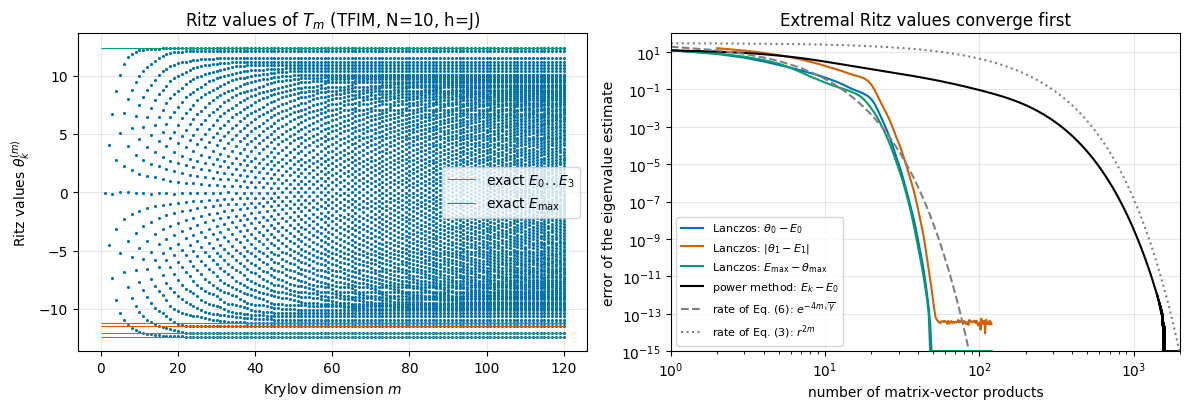

gamma = (E1-E0)/(Emax-E1) = 0.01222,  sqrt(gamma) = 0.1105
Lanczos reaches |theta_0 - E0| < 1e-10 at m = 43;  |theta_1 - E1| at m=120: 2.8e-14;  E_max error at m=120: -5.9e-14
power method reaches 1e-10 after 1183 iterations


In [12]:
# ==============================================================================
# EXPERIMENT 1: convergence of Ritz values vs Krylov dimension m  (N=10 critical TFIM)
# ==============================================================================
m_conv = 120
a_c, b_c, _ = lanczos(matvec_demo, v_start, m=m_conv, reorth=True)
ritz = ritz_history(a_c, b_c)                                   # list: ritz[k-1] = eigenvalues of T_k

gamma = (E1_ex - E0_ex) / (Emax_ex - E1_ex)
ks = np.arange(1, m_conv + 1)
err0 = np.array([r[0] - E0_ex for r in ritz])
err1 = np.array([r[1] - E1_ex if len(r) > 1 else np.nan for r in ritz])
errmax = np.array([Emax_ex - r[-1] for r in ritz])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
for k, r in zip(ks, ritz):
    axL.plot(np.full(len(r), k), r, ".", color=CB[0], ms=2.5)
axL.hlines(E_exact[:4], 0, m_conv, color=CB[1], lw=0.8, label="exact $E_0..E_3$")
axL.hlines(E_exact[-1], 0, m_conv, color=CB[2], lw=0.8, label=r"exact $E_{\max}$")
axL.set_xlabel("Krylov dimension $m$"); axL.set_ylabel(r"Ritz values $\theta_k^{(m)}$")
axL.set_title(f"Ritz values of $T_m$ (TFIM, N={N_demo}, h=J)"); axL.legend(loc="center right")

floor = 1e-15
axR.semilogy(ks, np.maximum(err0, floor), label=r"Lanczos: $\theta_0-E_0$")
axR.semilogy(ks, np.maximum(np.abs(err1), floor), label=r"Lanczos: $|\theta_1-E_1|$")
axR.semilogy(ks, np.maximum(errmax, floor), label=r"Lanczos: $E_{\max}-\theta_{\max}$")
axR.semilogy(np.arange(1, n_power + 1), np.maximum(np.asarray(E_power) - E0_ex, floor), color=CB[6], label="power method: $E_k-E_0$")
axR.semilogy(ks, 30 * np.exp(-4 * ks * np.sqrt(gamma)), "--", color="gray", label=r"rate of Eq. (6): $e^{-4m\sqrt{\gamma}}$")
axR.semilogy(np.arange(1, n_power + 1), 30 * r_theory ** (2 * np.arange(1, n_power + 1)), ":", color="gray", label=r"rate of Eq. (3): $r^{2m}$")
axR.set_xscale("log"); axR.set_xlim(1, n_power); axR.set_ylim(1e-15, 1e2)
axR.set_xlabel("number of matrix-vector products"); axR.set_ylabel("error of the eigenvalue estimate")
axR.set_title("Extremal Ritz values converge first"); axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

m_tol = int(np.argmax(err0 < 1e-10)) + 1
print(f"gamma = (E1-E0)/(Emax-E1) = {gamma:.5f},  sqrt(gamma) = {np.sqrt(gamma):.4f}")
print(f"Lanczos reaches |theta_0 - E0| < 1e-10 at m = {m_tol};  |theta_1 - E1| at m={m_conv}: {abs(err1[-1]):.1e};  E_max error at m={m_conv}: {errmax[-1]:.1e}")
k_pm = int(np.argmax(np.asarray(E_power) - E0_ex < 1e-10)) if np.any(np.asarray(E_power) - E0_ex < 1e-10) else None
print(f"power method reaches 1e-10 after {k_pm} iterations" if k_pm else
      f"power method: error still {float(E_power[-1]) - E0_ex:.1e} after {n_power} iterations")

**Reading the figure.**

* *Left:* at small $m$ the Ritz values are spread over the whole band; as $m$ grows, the outermost ones lock onto the exact extremal eigenvalues (horizontal lines) one after another, from
  the edges inwards. The interior of the fan keeps moving — $m=120$ numbers cannot represent a spectrum of 1024 levels, and they do not need to.
* *Right:* the error of $\theta_0$ falls exponentially with a slope close to the Chebyshev prediction $e^{-4m\sqrt\gamma}$ (dashed; only the slope is meaningful, the prefactor was chosen for visibility) until it hits the
  round-off floor $\sim10^{-14}$. The top of the spectrum converges similarly. The second-lowest Ritz value $\theta_1$ lags behind: it must first "wait" for $\theta_0$ to converge and is governed by the
  smaller relative gap $E_2-E_1$. The power method (black) decays exponentially as well, but with a far smaller rate, which on this *logarithmic* horizontal
  axis bends its curve and pushes it to the right: the printed numbers say that it needs about 1200 matrix–vector products for the accuracy that Lanczos
  reaches with about 40 — the order-of-magnitude difference promised by $\sqrt\gamma$ instead of $\gamma$ in the exponent.

> **Numerical practice.** Convergence is monitored *for free*: diagonalising $T_k$ at every step costs nothing compared with a matvec, and $\theta_0^{(k)}$ decreases monotonically.
> A common stopping rule is $|\theta_0^{(k)}-\theta_0^{(k-1)}|<\varepsilon$; a better one (Section 8) uses the residual.

## 7. What goes wrong in floating point: loss of orthogonality

### 7.1 The experiment

In exact arithmetic the three-term recurrence produces vectors that are orthogonal to *all* previous ones. In floating-point arithmetic each step commits a round-off error of relative size
$\varepsilon\approx10^{-16}$. One might hope that these errors stay small. They do not. We repeat the run of Section 5 with `lanczos_basic` for $m=150$ and look at the Gram matrix
$G_{ij}=\langle v_i|v_j\rangle$, which should be the identity.

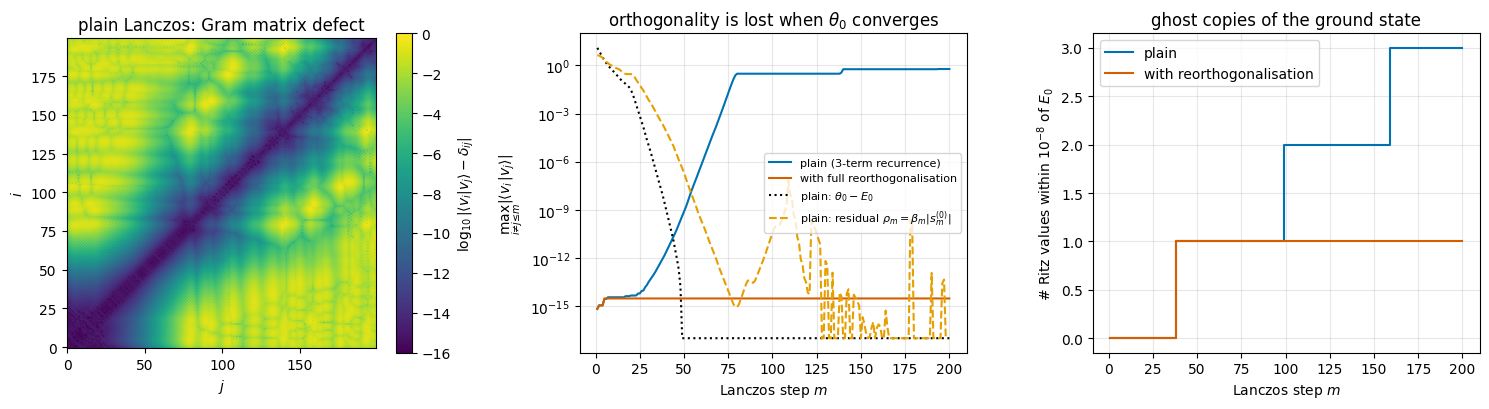

plain Lanczos : overlap between 'orthogonal' vectors exceeds 1e-3 at step m = 71; final max overlap = 0.59
reorthogonalised: max overlap after 200 steps = 3.0e-15
copies of E0 among the Ritz values at m=200: plain = 3, reorthogonalised = 1 (exact multiplicity: 1)
lowest Ritz value at m=200: plain -12.381489999655 | reorth -12.381489999655 | exact -12.381489999655

Paige's law:  (orthogonality defect) x (residual) stays at the round-off level  eps*||H|| = 2.7e-15
   m= 50:  max overlap 7.65e-10  x  rho_m 2.00e-07  =  1.53e-16
   m= 60:  max overlap 7.13e-07  x  rho_m 1.89e-10  =  1.35e-16
   m= 70:  max overlap 5.50e-04  x  rho_m 2.31e-13  =  1.27e-16
   m= 80:  max overlap 3.03e-01  x  rho_m 8.85e-16  =  2.68e-16
   m=100:  max overlap 3.03e-01  x  rho_m 3.62e-11  =  1.10e-11


In [13]:
# ==============================================================================
# EXPERIMENT 2: loss of orthogonality of plain Lanczos, and the ghost eigenvalues it creates
# ==============================================================================
m_long = 200
a_plain, b_plain, V_plain = lanczos_basic(matvec_demo, v_start, m_long)              # three-term recurrence only
a_reo, b_reo, V_reo = lanczos(matvec_demo, v_start, m=m_long, reorth=True)           # + full reorthogonalisation (engine)


def gram_defect(V):
    """|<v_i|v_j> - delta_ij|  for all pairs of Lanczos vectors (rows of V)."""
    Vf = V.reshape(V.shape[0], -1)
    return np.abs(np.asarray(jnp.conj(Vf) @ Vf.T) - np.eye(V.shape[0]))


def ground_residual_history(alphas, betas):
    """Cheap residual of the LOWEST Ritz pair of T_1, ..., T_{m-1}:   rho_k = beta_k |s^(0)_k|   [Eq. (8), Sec. 8.2].

    Only the last component of the lowest eigenvector of T_k is needed -- no big vectors, no matvec.
    """
    out = []
    for k in range(1, len(alphas)):
        _, S = np.linalg.eigh(tridiagonal(alphas, betas, k))
        out.append(betas[k - 1] * abs(S[-1, 0]))
    return np.array(out)


G_plain, G_reo = gram_defect(V_plain), gram_defect(V_reo)
ritz_plain = ritz_history(a_plain, b_plain)
ritz_reo = ritz_history(a_reo, b_reo)
res_plain = ground_residual_history(a_plain, b_plain)                # rho_k of the lowest Ritz pair
# orthogonality level after k steps = largest off-diagonal overlap among the first k vectors
orth_plain = [G_plain[:k, :k].max() for k in range(1, m_long + 1)]
orth_reo = [G_reo[:k, :k].max() for k in range(1, m_long + 1)]
# number of Ritz values closer than 1e-8 to the exact ground-state energy (true multiplicity: 1)
copies_plain = [int(np.sum(np.abs(r - E0_ex) < 1e-8)) for r in ritz_plain]
copies_reo = [int(np.sum(np.abs(r - E0_ex) < 1e-8)) for r in ritz_reo]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
im = axes[0].imshow(np.log10(G_plain + 1e-17), cmap="viridis", vmin=-16, vmax=0, origin="lower")
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}|\langle v_i|v_j\rangle-\delta_{ij}|$")
axes[0].set_xlabel("$j$"); axes[0].set_ylabel("$i$"); axes[0].set_title("plain Lanczos: Gram matrix defect"); axes[0].grid(False)

ks_long = np.arange(1, m_long + 1)
axes[1].semilogy(ks_long, np.maximum(orth_plain, 1e-17), label="plain (3-term recurrence)")
axes[1].semilogy(ks_long, np.maximum(orth_reo, 1e-17), label="with full reorthogonalisation")
axes[1].semilogy(ks_long, np.maximum([r[0] - E0_ex for r in ritz_plain], 1e-17), ":", color=CB[6], label=r"plain: $\theta_0-E_0$")
axes[1].semilogy(ks_long[:-1], np.maximum(res_plain, 1e-17), "--", color=CB[4], label=r"plain: residual $\rho_m=\beta_m|s_m^{(0)}|$")
axes[1].set_xlabel("Lanczos step $m$"); axes[1].set_ylabel(r"$\max_{i\neq j\leq m}|\langle v_i|v_j\rangle|$")
axes[1].set_title("orthogonality is lost when $\\theta_0$ converges"); axes[1].legend(fontsize=8)

axes[2].step(ks_long, copies_plain, where="post", label="plain")
axes[2].step(ks_long, copies_reo, where="post", label="with reorthogonalisation")
axes[2].set_xlabel("Lanczos step $m$"); axes[2].set_ylabel(r"# Ritz values within $10^{-8}$ of $E_0$")
axes[2].set_title("ghost copies of the ground state"); axes[2].legend()
plt.tight_layout(); plt.show()

m_lost = int(np.argmax(np.array(orth_plain) > 1e-3)) + 1
print(f"plain Lanczos : overlap between 'orthogonal' vectors exceeds 1e-3 at step m = {m_lost}; final max overlap = {orth_plain[-1]:.2f}")
print(f"reorthogonalised: max overlap after {m_long} steps = {orth_reo[-1]:.1e}")
print(f"copies of E0 among the Ritz values at m={m_long}: plain = {copies_plain[-1]}, reorthogonalised = {copies_reo[-1]} (exact multiplicity: 1)")
print(f"lowest Ritz value at m={m_long}: plain {ritz_plain[-1][0]:.12f} | reorth {ritz_reo[-1][0]:.12f} | exact {E0_ex:.12f}")
norm_H = max(abs(E0_ex), abs(Emax_ex))
print(f"\nPaige's law:  (orthogonality defect) x (residual) stays at the round-off level  eps*||H|| = {2.2e-16 * norm_H:.1e}")
for k in (50, 60, 70, 80, 100):
    print(f"   m={k:3d}:  max overlap {orth_plain[k - 1]:.2e}  x  rho_m {res_plain[k - 1]:.2e}  =  {orth_plain[k - 1] * res_plain[k - 1]:.2e}")

**What we see.**

* *Left/middle:* for the first few dozen steps the vectors are orthogonal to $\sim10^{-14}$. Then the overlaps grow **exponentially** and reach $O(1)$: the late Lanczos vectors are not even
  approximately orthogonal to the early ones. The dotted line shows *when* this happens: orthogonality collapses at the moment the first Ritz value converges. This is Paige's classic result
  (1971): round-off errors are amplified precisely in the direction of converged Ritz vectors. It is not a bug in our code; it is a property of the recurrence in finite precision.
  Paige's analysis is quantitative, and the printed table checks it. The component of the new vector along a Ritz vector whose residual is $\rho_m$ (Eq. (8) below) is of size

  $$ \big\vert\langle\tilde\psi_0\vert v_{m+1}\rangle\big\vert\;\approx\;\frac{\varepsilon\,\Vert H\Vert}{\rho_m}, $$

  so the *product* of the orthogonality defect and the residual should stay at the round-off level $\varepsilon\Vert H\Vert$ while each factor moves by ten orders of magnitude. The printed table shows exactly that:
  from $m=50$ to $m=80$ the overlap grows by about nine orders and the residual falls by seven to nine, while their product stays between $10^{-17}$ and $3\times10^{-16}$, one to two orders of
  magnitude below $\varepsilon\Vert H\Vert$ (Paige's relation carries an $O(1)$ constant). In the figure this is the orange curve falling as the blue one rises, the two crossing near $10^{-8}$. The last printed line, $m=100$, breaks the pattern because by then the
  overlaps have saturated at $O(1)$ and $\beta_m|s_m^{(0)}|$ has stopped being a residual at all: the identity that produces it (Eq. (7) below) assumes an orthonormal basis, which no longer exists. Loss of orthogonality
  is therefore not a slow accumulation of noise but the mirror image of convergence: the better the ground state is known, the faster the basis rots.
* *Right:* once orthogonality is lost, the algorithm "forgets" that it has already found the ground state and **finds it again**. The tridiagonal matrix acquires several eigenvalues
  equal to $E_0$ to many digits — so-called **ghost (spurious) eigenvalues** — although the true ground state is non-degenerate.

What did *not* go wrong: the lowest Ritz value is still correct (last printed line). Ghosts are copies of genuine eigenvalues, so plain Lanczos remains usable if one wants only $E_0$. But
multiplicities are wrong (a disaster if you want to count degenerate states or compute the gap as $\theta_1-\theta_0$: a ghost would give $\Delta=0$), convergence of the *other* eigenvalues is delayed, and the Krylov-space
formulas for time evolution used later in this chapter ([Krylov propagation](14_krylov_and_integrator_comparison.ipynb)) assume $V^\dagger V=\mathbb 1$.

### 7.2 The cure: full reorthogonalisation

The simplest fix is to stop trusting the three-term recurrence and explicitly project out **all** previous vectors after each step (one extra line in the loop):

$$ |w\rangle\;\leftarrow\;|w\rangle-\sum_{i\le j}|v_i\rangle\langle v_i|w\rangle . $$

In exact arithmetic the sum is zero; in floating point it removes the growing round-off components before they are amplified. This is what `reorth=True` does in the engine's `lanczos`, and the orange curves above show
that it keeps the basis orthonormal to machine precision and the multiplicity of $E_0$ at one. The price:

| | plain Lanczos | full reorthogonalisation |
|---|---|---|
| work per step | 1 matvec + $O(2^N)$ | 1 matvec + $O(j\,2^N)$ → total $O(m^2 2^N)$ |
| memory | 3 vectors (eigenvalues only) | all $m$ vectors: $m\,2^N$ numbers |

For spin chains one matvec costs $\sim 6N$ vector-sized operations, so for $m\lesssim100$ the overhead is comparable to the matvecs themselves — a fair price for robustness. Cheaper strategies exist (*selective* and *partial*
reorthogonalisation, which project only when and where needed; see Parlett's book) and **restarting** (Section 8.3) keeps $m$ small.

> **Common pitfall.** "My Lanczos finds a doubly degenerate ground state" — before announcing spontaneous symmetry breaking, check the orthogonality of your Krylov basis.

## 8. Ground-state vector, residual, restarts — and validation

### 8.1 From the small eigenvector to the big one

The eigenvector $s^{(0)}$ of $T_m$ holds the expansion coefficients of the approximate ground state in the Lanczos basis:

$$ |\tilde\psi_0\rangle=\sum_{j=1}^m s^{(0)}_j|v_j\rangle \qquad\Longleftrightarrow\qquad \texttt{jnp.tensordot(s0, V, axes=1)}\quad(V\text{ has shape }(m,2,\dots,2)). $$

This is why we store $V$: memory $m\,2^N$ complex numbers (for $N=20$, $m=80$: 1.3 GB in double precision — the real limit of the method on a laptop).

### 8.2 How good is it? The residual

On a large system there is no exact result to compare with. A **reference-free** quality measure is the residual norm

$$ \rho=\big\|H|\tilde\psi_0\rangle-\tilde E_0|\tilde\psi_0\rangle\big\|, $$

which vanishes iff $(\tilde E_0,\tilde\psi_0)$ is an exact eigenpair. Because $\tilde E_0=\langle\tilde\psi_0|H|\tilde\psi_0\rangle$ for a Ritz pair, and $\tilde\psi_0$ is normalised,
$\rho^2=\langle H^2\rangle-\langle H\rangle^2$ is the **energy variance**: an eigenstate is a state with zero energy fluctuations.

**The residual is free.** We do not even need the extra matrix–vector product. Collect the $m$ recurrence relations (5) into one matrix identity: applying $H$ to every column of $V_m=[v_1|\cdots|v_m]$ gives

$$ HV_m=V_mT_m+\beta_m\,|v_{m+1}\rangle\,e_m^{\mathsf T}, \qquad e_m=(0,\dots,0,1)^{\mathsf T}, \qquad(7)$$

because for $j<m$ the recurrence closes inside the basis, while at $j=m$ the new direction $\beta_m|v_{m+1}\rangle$ sticks out of it. Apply Eq. (7) to the eigenvector $s^{(0)}$ of $T_m$ with $T_ms^{(0)}=\theta_0s^{(0)}$:

$$ H|\tilde\psi_0\rangle-\theta_0|\tilde\psi_0\rangle=V_m\big(T_ms^{(0)}-\theta_0s^{(0)}\big)+\beta_m\,|v_{m+1}\rangle\,s^{(0)}_m=\beta_m\,s^{(0)}_m\,|v_{m+1}\rangle, $$

and since $|v_{m+1}\rangle$ is a unit vector,

$$ \rho=\beta_m\,\big\vert s^{(0)}_m\big\vert \qquad\text{(8)} $$

— the last off-diagonal element of $T$ times the **last component** of the small eigenvector. Both are already on hand, so the convergence of every Ritz pair can be monitored at every step for the price of an $m\times m$ diagonalisation.
Exercise 4 asks you to verify Eq. (8) against the definition; the function `residual_norm` below does it the expensive way, with one extra matvec, precisely so that the check is independent.

**What the number means.** Two standard results turn $\rho$ into an error bar. (i) There is always an exact eigenvalue within distance $\rho$ of $\tilde E_0$. (ii) If the gap $\Delta$ from $\tilde E_0$ to the *rest* of the spectrum is
known, both errors are much smaller (Kato–Temple and Davis–Kahan; see Parlett):

$$ |\tilde E_0-E_0|\;\le\;\frac{\rho^2}{\Delta},\qquad \sin\angle(\tilde\psi_0,\psi_0)\;\le\;\frac{\rho}{\Delta}. $$

> **Numerical practice.** Stop on the residual, not on the change of the energy. The rule of thumb that follows from the two bounds: iterate until $\rho\ll\Delta$ if you want the *state* (a wave function accurate to $10^{-6}$ needs
> $\rho\approx10^{-6}\Delta$), and until $\rho\lesssim\sqrt{\varepsilon\Delta}$ if you only want the *energy* to accuracy $\varepsilon$. Energies are cheap, states are expensive — and the ratio of the two costs is $\Delta$ itself,
> which is why a nearly degenerate problem is hard even when its ground-state energy comes out to twelve digits. $\Delta$ is not known a priori, but the Ritz values supply an estimate: $\theta_1^{(m)}-\theta_0^{(m)}$ is a lower bound
> on the true gap that improves as the run proceeds.

### 8.3 Restarts

If $m$ steps are not enough and memory forbids a larger $m$, **restart**: use the current Ritz vector $|\tilde\psi_0\rangle$ as the new start vector and run another $m$ steps. Since $|\tilde\psi_0\rangle$ already has a large overlap with the
ground state ($\tan\varphi$ in Eq. (6) is small), each restart improves the result. The engine's `lanczos_ground_state(terms, N, m, restarts)` does exactly this; its source is in the Engine recap and uses nothing beyond the
preceding sections. This *explicit* restart throws away everything the run learned except one vector. Production libraries instead keep the best few Ritz vectors and filter out the rest with a polynomial — **implicitly restarted**
(or thick-restarted) Lanczos, the algorithm inside ARPACK and therefore inside `scipy.sparse.linalg.eigsh` (Lehoucq, Sorensen & Yang; Saad).

### 8.4 Checkpoint: engine solver vs dense diagonalisation

In [14]:
# ==============================================================================
# CHECKPOINT 4: lanczos_ground_state (engine)  vs  dense eigh   -- energy, state fidelity, residual
# ==============================================================================
def residual_norm(terms, E, psi):
    """rho = || H psi - E psi ||   (reference-free error estimate; rho^2 = energy variance for E = <H>)."""
    return float(jnp.linalg.norm(apply_hamiltonian(terms, psi) - E * psi))


validation_models = {
    "TFIM chain   N=10, h/J=1.0": tfim_terms(10, 1.0, 1.0),
    "TFIM chain   N=10, h/J=1.5": tfim_terms(10, 1.0, 1.5),
    "XXZ ring     N=10, Delta=1": xxz_terms(10, 1.0, 1.0, bonds=chain_bonds(10, periodic=True)),
    "TFIM ladder  5x2,  h/J=2.0": tfim_terms(10, 1.0, 2.0, bonds=grid_bonds(5, 2)),
}
for name, terms_v in validation_models.items():
    E_lan, psi_lan = lanczos_ground_state(terms_v, 10, m=50, restarts=2)
    w_dense, U_dense = np.linalg.eigh(np.asarray(dense_hamiltonian(terms_v, 10)))
    fid = abs(np.vdot(U_dense[:, 0], np.asarray(psi_lan).reshape(-1))) ** 2
    res = residual_norm(terms_v, E_lan, psi_lan)
    print(f"{name}:  E0 = {E_lan:+.10f}  |dE| = {abs(E_lan - w_dense[0]):.1e}   1-fidelity = {abs(1 - fid):.1e}   residual = {res:.1e}")
    assert abs(E_lan - w_dense[0]) < 1e3 * TOL and abs(1 - fid) < 1e3 * TOL

TFIM chain   N=10, h/J=1.0:  E0 = -12.3814899997  |dE| = 1.4e-14   1-fidelity = 1.3e-15   residual = 1.7e-14


TFIM chain   N=10, h/J=1.5:  E0 = -16.5352549468  |dE| = 2.1e-14   1-fidelity = 3.6e-15   residual = 2.6e-14


XXZ ring     N=10, Delta=1:  E0 = -18.0617854180  |dE| = 1.8e-14   1-fidelity = 4.4e-16   residual = 2.7e-14


TFIM ladder  5x2,  h/J=2.0:  E0 = -21.8940497128  |dE| = 1.1e-14   1-fidelity = 2.2e-16   residual = 1.7e-14


Energies agree with dense diagonalisation to $\sim10^{-13}$, the states have fidelity one up to round-off, and the residuals — which we could have computed *without* knowing the exact answer — are tiny.
All four Hamiltonians went through the same ten lines of code; only the list of terms changed.

> **Common pitfall.** We deliberately did *not* include the ordered phase of the Ising chain ($h<J$) in this table. There the two lowest states are separated by a gap that is exponentially small in $N$,
> Eq. (6) predicts extremely slow convergence *of the state* (the energy is fine), and the Ritz vector is an arbitrary mixture of the two. Section 10 shows how symmetry solves this problem.

## 9. JAX practice: Lanczos as a compiled `lax.scan`, and `vmap` over a Hamiltonian parameter

The engine's `lanczos` is a Python loop: flexible (it can stop early when $\beta_j\to0$) but each of its $O(m^2)$ small operations is dispatched from Python, and the loop cannot be placed inside `jit` or `vmap`.
For production sweeps — the same calculation for many values of $h$ — we want the **whole solver** to be one compiled function of the Hamiltonian parameters. Three design decisions make this possible:

1. **Fixed number of steps $m$** (no data-dependent `break`): shapes must be static under `jit`. We guard against breakdown with `jnp.where` instead of `if`.
2. **Pre-allocated basis** `V` of shape `(m, 2^N)`, filled row by row with `V.at[j+1].set(...)`. Rows that are not yet filled are zero, so projecting on *all* rows is harmless — and turns the
   reorthogonalisation loop into **two matrix–vector products**: $c=V^*w$ (all overlaps $\langle v_i|w\rangle$ at once), $w\leftarrow w-c\,V$.
3. The small eigenproblem is solved with `jnp.linalg.eigh` on the dense $m\times m$ matrix $T$ — inside the same compiled function.

The einsum/matmul translation of the projection: with row $i$ of `V` holding $v_i$, the overlaps are $c_i=\sum_d V_{id}^*w_d$. The literal transcription `jnp.conj(V) @ w` would build the complex conjugate of the whole
basis, $m\,2^N$ numbers. Using $\overline{\sum_d V_{id}\bar w_d}=\sum_d V_{id}^*w_d$ we instead write `jnp.conj(V @ jnp.conj(w))`, which conjugates the single vector $w$ ($2^N$ numbers) and the $m$-component result:
one pass over a vector instead of one pass over the basis.

In [15]:
# ==============================================================================
# STEP 5: Lanczos with full reorthogonalisation as a lax.scan  (jit- and vmap-able)
# ==============================================================================
def lanczos_scan(matvec, v0, m, n_reorth=1):
    """m Lanczos steps with full reorthogonalisation, as ONE lax.scan.

    MATH      beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1};   then  w <- w - sum_i v_i <v_i|w>   (n_reorth times)
    CARRY     (V, v_j, v_{j-1}, beta_{j-1});  V has static shape (m, 2^N), rows j+1.. are still zero at step j.
    RETURNS   alphas (m,), betas (m-1,), V (m, 2^N).
    JAX       static m; no Python branching on values (breakdown beta ~ 0 handled by jnp.where -> v_{j+1} = 0,
              which decouples the rest of T as harmless zero rows);  `mode="drop"` ignores the out-of-range write at j = m-1.
    COST      m matvecs + m * n_reorth * 2 products with V (each O(m 2^N));  memory m 2^N.
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def body(carry, j):
        V, v, v_prev, beta_prev = carry
        w = matvec(v.reshape(shape)).reshape(-1)
        alpha = jnp.real(jnp.vdot(v, w))
        w = w - alpha * v - beta_prev * v_prev
        for _ in range(n_reorth):                              # static Python loop (unrolled at trace time)
            w = w - jnp.conj(V @ jnp.conj(w)) @ V              # w - sum_i v_i <v_i|w>
        beta = jnp.linalg.norm(w)
        v_next = jnp.where(beta > 1e-10, w / jnp.where(beta > 1e-10, beta, 1.0), 0.0)
        V = V.at[j + 1].set(v_next, mode="drop")
        return (V, v_next, v, beta.astype(w.real.dtype)), (alpha, beta)

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=v0.real.dtype))
    (V, _, _, _), (alphas, betas) = lax.scan(body, init, jnp.arange(m))
    return alphas, betas[:-1], V


def ground_state_scan(terms, v0, m):
    """Lowest eigenpair of H = sum(terms) in the Krylov space of v0.  Returns (E0, psi0 [tensor], residual norm).
    Everything -- recurrence, small eigenproblem, Ritz vector, residual -- is traceable: wrap it in jax.jit."""
    alphas, betas, V = lanczos_scan(lambda p: apply_hamiltonian(terms, p), v0, m)
    T = jnp.diag(alphas) + jnp.diag(betas, 1) + jnp.diag(betas, -1)
    theta, S = jnp.linalg.eigh(T)
    psi = (S[:, 0].astype(V.dtype) @ V).reshape(v0.shape)      # Ritz vector  sum_j s_j v_j
    psi = psi / jnp.linalg.norm(psi)
    res = jnp.linalg.norm(apply_hamiltonian(terms, psi) - theta[0] * psi)
    return theta[0], psi, res


# ------------------------------------------------------------------------------
# agreement with the Python-loop engine version, and timing (N = 12)
# ------------------------------------------------------------------------------
N_t, m_t = 12, 60
terms_t = tfim_terms(N_t, 1.0, 1.0)
v_t = haar_state(jax.random.PRNGKey(3), N_t)
mv_t = jax.jit(lambda p: apply_hamiltonian(terms_t, p))
_ = mv_t(v_t).block_until_ready()                                     # compile the matvec outside the timed region

t0 = time.time(); a_py, b_py, _ = lanczos(mv_t, v_t, m=m_t, reorth=True); t_py = time.time() - t0

scan_fn = jax.jit(lambda v: lanczos_scan(mv_t, v, m_t))
t0 = time.time(); out = scan_fn(v_t); out[0].block_until_ready(); t_compile = time.time() - t0
t0 = time.time(); a_sc, b_sc, V_sc = scan_fn(v_t); a_sc.block_until_ready(); t_run = time.time() - t0

th_py = np.linalg.eigvalsh(tridiagonal(a_py, b_py))[0]
th_sc = np.linalg.eigvalsh(tridiagonal(np.asarray(a_sc), np.asarray(b_sc)))[0]
orth_sc = float(jnp.max(jnp.abs(jnp.conj(V_sc) @ V_sc.T - jnp.eye(m_t))))
print(f"lowest Ritz value: python loop {th_py:.12f} | scan {th_sc:.12f} | difference {abs(th_py - th_sc):.1e}")
print(f"orthogonality of the scan basis: max|V^dag V - 1| = {orth_sc:.1e}")
print(f"time for m={m_t}, N={N_t}:  python loop {t_py:.2f} s | scan: first call (compile+run) {t_compile:.2f} s, second call {t_run:.3f} s")
assert abs(th_py - th_sc) < 1e3 * TOL and orth_sc < 1e4 * TOL

lowest Ritz value: python loop -14.925971109909 | scan -14.925971109909 | difference 1.2e-14
orthogonality of the scan basis: max|V^dag V - 1| = 8.9e-16
time for m=60, N=12:  python loop 0.28 s | scan: first call (compile+run) 0.35 s, second call 0.046 s


The two implementations agree to round-off and the scan basis is orthonormal to machine precision with a single projection pass per step. The compiled version pays a one-time compilation cost and is then
much faster than the Python loop at this size, where Python dispatch overhead ($O(m^2)$ tiny operations) dominates. (At $N\gtrsim18$ the floating-point work dominates and the two become comparable.)

**Sweeping a parameter with `vmap`.** Because `spin_hamiltonian_terms` accepts traced couplings, `ground_state_scan(tfim_terms(N, J, h), v0, m)` is a differentiable, batchable function of $h$.
`jax.vmap` turns it into a function of a whole *array* of fields, executed as one batched program: every einsum gets an extra batch axis, no Python loop. The memory grows with the batch
(`len(hs)` Krylov bases), so for the largest systems we will fall back to a Python loop over the *same compiled function* — it is compiled once, because `h` is a traced argument, not a constant.

In [16]:
# ==============================================================================
# DEMO: ground-state energy for 15 values of the field in ONE batched call (N = 10)
# ==============================================================================
hs_demo = jnp.linspace(0.25, 2.0, 15)
solve_h = lambda h: ground_state_scan(tfim_terms(N_demo, 1.0, h), v_start, 60)[0]      # h -> E0(h)
E_batch = jax.jit(jax.vmap(solve_h))(hs_demo)                                          # all fields at once
E_dense = np.array([np.linalg.eigvalsh(np.asarray(dense_hamiltonian(tfim_terms(N_demo, 1.0, float(h)), N_demo)))[0]
                    for h in hs_demo[::7]])                                            # dense check on 3 of them
print("h      :", np.round(np.asarray(hs_demo[::7]), 3))
print("vmap E0:", np.asarray(E_batch[::7]))
print("dense  :", E_dense)
print(f"max deviation: {np.max(np.abs(np.asarray(E_batch[::7]) - E_dense)):.1e}")
assert np.max(np.abs(np.asarray(E_batch[::7]) - E_dense)) < 1e4 * TOL

h      : [0.25  1.125 2.   ]
vmap E0: [ -9.18837108 -13.33937368 -21.13931912]
dense  : [ -9.18837108 -13.33937368 -21.13931912]
max deviation: 8.7e-14


## 10. Symmetry sectors: excited states and the gap

### 10.1 Krylov spaces respect symmetries

Let $Q$ be a symmetry, $[H,Q]=0$, and let the start vector be an eigenvector of $Q$: $Q|v\rangle=q|v\rangle$. Then
$QH^k|v\rangle=H^kQ|v\rangle=q\,H^k|v\rangle$: **every Krylov vector stays in the same symmetry sector**. Lanczos started in a sector therefore converges to the lowest state *of that sector* and
never sees the others. This is useful in three ways:

1. **Excited states for free.** The lowest states of different sectors are often the lowest states overall. For the TFIM the ground state has parity $P=+1$ and the first excited state has $P=-1$, so
   $\Delta=E_0^{(P=-1)}-E_0^{(P=+1)}$: two *ground-state* calculations, each with the fast convergence of an extremal eigenvalue.
2. **Near-degeneracies disappear.** In the ordered phase the two lowest levels are split by an exponentially small amount; within one sector, the nearest level is a finite distance away, so the relative gap $\gamma$ in Eq. (6) is of order one again.
3. **Clean states.** The Ritz vector has exact quantum numbers, instead of being an arbitrary mixture of nearly degenerate states.

### 10.2 Projecting the start vector

For a symmetry with $Q^2=1$ (like the parity $P$), the projector on the sector $q=\pm1$ is $\Pi_\pm=(1\pm P)/2$: apply it to a random vector and normalise. For the magnetisation $M=\sum_iZ_i$, which is diagonal in the
computational basis, the projector on $M=M_0$ is a **mask**: keep the amplitudes $\psi[s_0..s_{N-1}]$ whose bit string has the right number of up-spins, zero the others. We build the array $M(s)=\sum_q(1-2s_q)$ with the
same broadcasting trick that the engine uses for one-axis twisting: site $q$ contributes an array of shape $(1,..,2,..,1)$ with entries $(+1,-1)$ along axis $q$, and NumPy broadcasting adds them up to a full $(2,)^N$ tensor.

In floating-point arithmetic round-off continuously re-injects tiny ($10^{-16}$) components of the other sectors, and Lanczos amplifies whichever of them belongs to a *lower* eigenvalue — for the odd sector, the true
ground state. Full reorthogonalisation does not help here: those components are orthogonal to nothing in particular, they simply ride along inside every $v_j$.

> **Numerical practice.** There are two defences, and they cost almost nothing. (i) *Monitor*: print $\langle Q\rangle$ of the final state; a value that has drifted from $\pm1$ means the run has leaked. (ii) *Enforce*: apply the
> projector to $w$ once per Lanczos step. Because $[\Pi_\pm,H]=0$, projecting does not change the exact Krylov space — it only removes the round-off leak — and for the parity it is one `jnp.flip` per step, i.e. one pass over
> $2^N$ numbers against the $\sim6N$ passes of a matvec. Below we use (i), because at the Krylov dimensions of this notebook the leak stays at the $10^{-15}$ level; switch to (ii) for long runs or tiny sector gaps.

In [17]:
# ==============================================================================
# STEP 6: symmetry projectors for start vectors
# ==============================================================================
def project_parity(psi, sign):
    """Projector (1 + sign*P)/2 on the spin-flip parity sector P = sign (+1 or -1), followed by normalisation."""
    out = psi + sign * apply_parity(psi)
    return out / jnp.linalg.norm(out)


def magnetisation_tensor(N):
    """M(s) = sum_q (1 - 2 s_q) as a real tensor of shape (2,)*N, assembled by broadcasting N small arrays."""
    return sum(jnp.array([1.0, -1.0]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))


def project_magnetisation(psi, M0=0):
    """Keep only basis states with total magnetisation M = sum_i Z_i equal to M0 (a mask), then normalise."""
    out = jnp.where(magnetisation_tensor(psi.ndim) == M0, psi, 0.0)
    return out / jnp.linalg.norm(out)


def parity_expectation(psi):
    """<psi|P|psi>  (exactly +1 or -1 for a state inside one parity sector)."""
    return float(jnp.real(jnp.vdot(psi, apply_parity(psi))))


# ------------------------------------------------------------------------------
# CHECKPOINT 5: the two lowest levels of the TFIM from two sector ground states (N=10, dense reference)
# ------------------------------------------------------------------------------
solver_demo = jax.jit(lambda h, v0: ground_state_scan(tfim_terms(N_demo, 1.0, h), v0, 60))
v_even, v_odd = project_parity(v_start, +1), project_parity(v_start, -1)
print("  h/J     E0 (P=+1) error   E1 (P=-1) error   gap (sectors)   gap (dense)    <P> of the two states")
for h_val in (0.5, 1.0, 1.5):
    Ee, psi_e, _ = solver_demo(h_val, v_even)
    Eo, psi_o, _ = solver_demo(h_val, v_odd)
    w_d = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(tfim_terms(N_demo, 1.0, h_val), N_demo)))
    print(f"  {h_val:.1f}     {abs(float(Ee) - w_d[0]):.1e}           {abs(float(Eo) - w_d[1]):.1e}           {float(Eo - Ee):.8f}      {w_d[1] - w_d[0]:.8f}"
          f"     {parity_expectation(psi_e):+.6f}, {parity_expectation(psi_o):+.6f}")
    assert abs(float(Eo - Ee) - (w_d[1] - w_d[0])) < 1e4 * TOL

  h/J     E0 (P=+1) error   E1 (P=-1) error   gap (sectors)   gap (dense)    <P> of the two states


  0.5     1.6e-14           1.1e-14           0.00146485      0.00146485     +1.000000, -1.000000


  1.0     5.3e-14           3.7e-14           0.29892037      0.29892037     +1.000000, -1.000000


  1.5     2.8e-14           4.6e-14           1.16723758      1.16723758     +1.000000, -1.000000


The two sector ground states reproduce the two lowest levels of the dense spectrum — including the tiny splitting in the ordered phase ($h/J=0.5$), which a single Lanczos run would struggle to resolve — and
the final states still have parity $\pm1$ to the printed precision.

### 10.3 A first physics result: how a finite magnet decides

The tiny splitting at $h=0.5J$ answers a physical question: why does a *finite* magnet not order? The two sector ground states are, to a good approximation, the even and odd
combinations $(|\!\uparrow\cdots\uparrow\rangle\pm|\!\downarrow\cdots\downarrow\rangle)/\sqrt2$ of the two ferromagnets. The field $-hX_i$ flips one spin at a time, so connecting all up
to all down takes $N$ flips, each through states with domain walls that cost an energy of order $J$: the tunnelling amplitude, and with it the splitting, is of order $N$ in $h/J$,
$E_1-E_0\propto J(h/J)^N$.

**The prefactor from the free-fermion solution.** In the exact solution of Section 11.2 the gap is twice the smallest singular value $s_N$ of the bidiagonal matrix $B$ with $h$ on the diagonal and
$J$ above it. With $\lambda=h/J<1$, the geometric vector $x_n=(-\lambda)^n$ satisfies the rows $hx_n+Jx_{n+1}=0$ of $Bx=0$ for $n=0,\dots,N-2$ exactly; only the last row is left over,
$(Bx)_{N-1}=hx_{N-1}$, of size $J\lambda^N$. Likewise $y_n=(-\lambda)^{N-1-n}$ satisfies all rows of $B^{\mathsf T}y=0$ except the first. These are the zero modes at the two ends of the chain, and
the approximate singular pair gives

$$ s_N\approx\frac{|y^{\mathsf T}Bx|}{\|x\|\,\|y\|}=\frac{|y_{N-1}(Bx)_{N-1}|}{\|x\|\,\|y\|}=\frac{J\lambda^N}{1/(1-\lambda^2)},\qquad
   E_1-E_0=2s_N\approx2J\,(1-\lambda^2)\,\lambda^N , $$

using $y_{N-1}=1$ and $\|x\|^2=\|y\|^2=\sum_n\lambda^{2n}\approx1/(1-\lambda^2)$. For $h=0.5J$ this is $1.5J\cdot2^{-N}$: every four added spins divide the splitting by $16$.
The cell below compares it with the Lanczos sector gaps.

**What it means.** The ground state of the finite chain is always the symmetric cat, but the time needed to tunnel from one ferromagnet to the other, $\hbar/(E_1-E_0)$, grows exponentially with $N$
— for two hundred spins at $h=0.5J$ and $J$ of one millielectronvolt it exceeds the age of the universe by thirty orders of magnitude. A magnet prepared in one of the two states stays there.
This is how spontaneous symmetry breaking looks on a finite system, and it is why the sector method, which keeps the two levels apart, is indispensable.

In [18]:
# ==============================================================================
# CHECKPOINT: the tunnelling splitting 2J(1 - lambda^2) lambda^N in the ordered phase (h = 0.5 J)
# ==============================================================================
h_ord = 0.5
for N in (8, 10, 12, 14):
    solve_N = jax.jit(lambda h, v0, N=N: ground_state_scan(tfim_terms(N, 1.0, h), v0, 60)[0])
    v_rand = haar_state(jax.random.PRNGKey(500 + N), N)
    split = float(solve_N(h_ord, project_parity(v_rand, -1)) - solve_N(h_ord, project_parity(v_rand, +1)))
    formula = 2 * (1 - h_ord ** 2) * h_ord ** N
    print(f"N={N:2d}: Lanczos sector splitting {split:.6e}   2J(1-lambda^2)lambda^N = {formula:.6e}   ratio {split / formula:.5f}")
    assert abs(split / formula - 1) < 1e-3

N= 8: Lanczos sector splitting 5.859889e-03   2J(1-lambda^2)lambda^N = 5.859375e-03   ratio 1.00009


N=10: Lanczos sector splitting 1.464854e-03   2J(1-lambda^2)lambda^N = 1.464844e-03   ratio 1.00001


N=12: Lanczos sector splitting 3.662111e-04   2J(1-lambda^2)lambda^N = 3.662109e-04   ratio 1.00000


N=14: Lanczos sector splitting 9.155274e-05   2J(1-lambda^2)lambda^N = 9.155273e-05   ratio 1.00000


## 11. Physics I: the quantum phase transition of the Ising chain

### 11.1 What to expect

For $h\ll J$ the ground state is ferromagnetic; for $h\gg J$ all spins point along $x$. In the thermodynamic limit the two regimes are separated by a **quantum critical point at $h=J$** (Pfeuty 1970), where the gap closes as
$\Delta=2|h-J|$ and correlations decay as power laws. On a finite chain nothing is singular, but the transition leaves clear fingerprints, which we now compute for $N=8,12,16$:

* the **gap** $\Delta(h)$ between the $P=\pm1$ sector ground states;
* the **transverse magnetisation** $m_x=\frac1N\sum_i\langle X_i\rangle$;
* the **order parameter**. $\langle Z_i\rangle$ itself vanishes identically in a parity eigenstate ($PZ_iP=-Z_i$), so we use the squared magnetisation
  $m_z^2=\langle M^2\rangle/N^2=\frac1{N^2}\sum_{ij}\langle Z_iZ_j\rangle$, computed matrix-free as $\|M|\psi\rangle\|^2/N^2$;
* the **half-chain entanglement entropy** $S_{N/2}$ (in bits).

### 11.2 An exact benchmark at every $N$

The TFIM chain is one of the few exactly solvable many-body models: a Jordan–Wigner transformation maps it onto non-interacting fermions (Lieb, Schultz & Mattis 1961; Pfeuty 1970). We quote the result for the **open** chain
without proof: let $s_1\ge\dots\ge s_N>0$ be the singular values of the $N\times N$ bidiagonal matrix with $h$ on the diagonal and $J$ on the first superdiagonal. Then, in our Pauli convention,

$$ E_0=-\sum_{k=1}^Ns_k,\qquad \Delta=E_1-E_0=2\,s_N . $$

This costs $O(N^3)$ instead of $O(2^N)$ and gives us an independent check of the many-body calculation at sizes where dense diagonalisation is impossible. (Such luck is rare: add a field $h_zZ_i$ or a next-nearest-neighbour coupling and
the model is no longer solvable, while our code does not care.)

In [19]:
# ==============================================================================
# EXPERIMENT 3: TFIM chain, sweep of the transverse field for N = 8, 12, 16
# ==============================================================================
def tfim_free_fermion(N, J, h):
    """Exact (E0, gap) of the OPEN TFIM chain from free fermions: singular values of the bidiagonal matrix (h on diag, J above)."""
    s = np.linalg.svd(np.diag(np.full(N, float(h))) + np.diag(np.full(N - 1, float(J)), 1), compute_uv=False)
    return -s.sum(), 2 * s.min()


def make_tfim_solver(N, m, bonds=None, weights=None):
    """Returns a jitted function (h, v0) -> dict of ground-state properties of the TFIM on the given graph."""
    def solve(h, v0):
        terms = tfim_terms(N, 1.0, h, bonds=bonds, weights=weights)
        E0, psi, res = ground_state_scan(terms, v0, m)
        mx = jnp.mean(jnp.stack([expect_local(psi, X, [q]) for q in range(N)]))          # (1/N) sum_i <X_i>
        Mpsi = apply_magnetisation(psi)
        mz2 = jnp.real(jnp.vdot(Mpsi, Mpsi)) / N ** 2                                     # <M^2>/N^2
        S_half = entanglement_entropy(psi, range(N // 2))                                 # bits
        return {"E0": E0, "res": res, "mx": mx, "mz2": mz2, "S": S_half}
    return jax.jit(solve)


# ------------------------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------------------------
sizes = (8, 12, 16)
hs = np.linspace(0.25, 2.0, 8)           # step 0.25, contains h = 0.5 and h = 1 exactly
m_krylov = 70                            # Krylov dimension; the printed errors below show how well it converges
results = {}
t_start = time.time()
for N in sizes:
    v_rand = haar_state(jax.random.PRNGKey(100 + N), N)
    v_even, v_odd = project_parity(v_rand, +1), project_parity(v_rand, -1)
    solver = make_tfim_solver(N, m_krylov)
    if N <= 12:                                       # small: all fields at once with vmap
        even = jax.vmap(solver, in_axes=(0, None))(jnp.asarray(hs), v_even)
        odd = jax.vmap(solver, in_axes=(0, None))(jnp.asarray(hs), v_odd)
    else:                                             # large: loop over the SAME compiled function (caps memory)
        runs_e = [solver(h, v_even) for h in hs]
        runs_o = [solver(h, v_odd) for h in hs]
        even = {k: jnp.stack([r[k] for r in runs_e]) for k in runs_e[0]}
        odd = {k: jnp.stack([r[k] for r in runs_o]) for k in runs_o[0]}
    results[N] = {k: np.asarray(v) for k, v in even.items()}
    results[N]["gap"] = np.asarray(odd["E0"]) - np.asarray(even["E0"])
    results[N]["res_odd"] = np.asarray(odd["res"])
    ff = np.array([tfim_free_fermion(N, 1.0, h) for h in hs])
    results[N]["err_E0"] = np.max(np.abs(results[N]["E0"] - ff[:, 0]))
    results[N]["err_gap"] = np.max(np.abs(results[N]["gap"] - ff[:, 1]))
    print(f"N={N:2d}: max|E0 - E0_exact| = {results[N]['err_E0']:.1e}   max|gap - gap_exact| = {results[N]['err_gap']:.1e}   "
          f"max residual (even/odd) = {results[N]['res'].max():.1e} / {results[N]['res_odd'].max():.1e}   [{time.time() - t_start:.0f} s]")
    assert results[N]["err_E0"] < 1e4 * TOL and results[N]["err_gap"] < 1e5 * TOL

N= 8: max|E0 - E0_exact| = 7.1e-15   max|gap - gap_exact| = 6.0e-15   max residual (even/odd) = 1.6e-14 / 1.4e-14   [1 s]


N=12: max|E0 - E0_exact| = 7.1e-15   max|gap - gap_exact| = 9.2e-15   max residual (even/odd) = 3.4e-14 / 2.9e-09   [2 s]


N=16: max|E0 - E0_exact| = 1.8e-14   max|gap - gap_exact| = 2.9e-08   max residual (even/odd) = 5.2e-09 / 5.7e-04   [27 s]


**Checkpoint passed at every size**, including $N=16$ (Hilbert-space dimension 65 536, where the dense matrix would need 69 GB): the ground-state energies agree with the free-fermion solution to round-off and the gaps to
a few parts in $10^8$. The residuals tell the same story without using the exact solution, and they show *where* the Krylov space of fixed dimension $m=70$ is working hardest: the odd-sector residual at large $h$ is several orders
of magnitude above the even one, because the lowest $P=-1$ states there form a band of closely spaced one-particle levels — a small relative gap $\gamma$ in Eq. (6). Even so the *energy* error stays tiny, because it is quadratic
in the residual ($\rho\approx6\times10^{-4}$ and a gap $\Delta\approx3J$ to the next odd state give $\rho^2/\Delta\sim10^{-7}$, and the measured gap error is $3\times10^{-8}$). Raising $m$ to 80 lowers the worst gap error from
$3\times10^{-8}$ to $1\times10^{-11}$ for about a third more time (measured on this machine); try it.

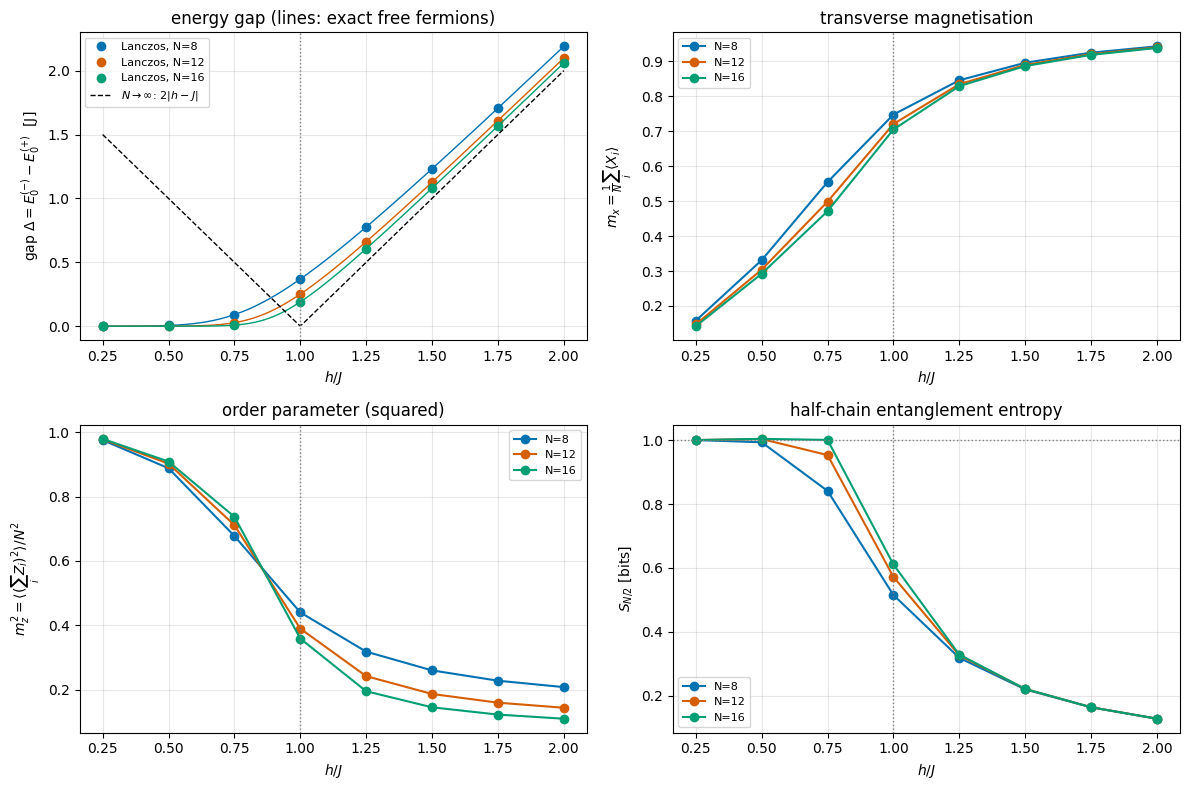

N= 8:  gap(h=0.5J) = 5.86e-03   gap(h=J) = 0.3691   m_z^2(h=0.5J) = 0.888   m_z^2(h=2J) = 0.208  [1/N = 0.125]   S(h=0.25J) = 1.0002   S(h=J) = 0.5153
        at h=J:  m_z^2 = 0.4404,  N^(1/4) m_z^2 = 0.7406   |   h where m_z^2 = 1/2:  0.9372 J
N=12:  gap(h=0.5J) = 3.66e-04   gap(h=J) = 0.2512   m_z^2(h=0.5J) = 0.902   m_z^2(h=2J) = 0.144  [1/N = 0.083]   S(h=0.25J) = 1.0003   S(h=J) = 0.5721
        at h=J:  m_z^2 = 0.3900,  N^(1/4) m_z^2 = 0.7259   |   h where m_z^2 = 1/2:  0.9144 J
N=16:  gap(h=0.5J) = 2.29e-05   gap(h=J) = 0.1903   m_z^2(h=0.5J) = 0.909   m_z^2(h=2J) = 0.110  [1/N = 0.062]   S(h=0.25J) = 1.0003   S(h=J) = 0.6109
        at h=J:  m_z^2 = 0.3592,  N^(1/4) m_z^2 = 0.7183   |   h where m_z^2 = 1/2:  0.9069 J


In [20]:
# ==============================================================================
# FIGURE: fingerprints of the quantum critical point
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
h_fine = np.linspace(0.25, 2.0, 200)
for c, N in zip(CB, sizes):
    r = results[N]
    axes[0, 0].plot(hs, r["gap"], "o", color=c, label=f"Lanczos, N={N}")
    axes[0, 0].plot(h_fine, [tfim_free_fermion(N, 1.0, h)[1] for h in h_fine], "-", color=c, lw=1)
    axes[0, 1].plot(hs, r["mx"], "o-", color=c, label=f"N={N}")
    axes[1, 0].plot(hs, r["mz2"], "o-", color=c, label=f"N={N}")
    axes[1, 1].plot(hs, r["S"], "o-", color=c, label=f"N={N}")
axes[0, 0].plot(h_fine, 2 * np.abs(h_fine - 1), "k--", lw=1, label=r"$N\to\infty$: $2|h-J|$")
axes[0, 0].set_ylabel(r"gap $\Delta=E_0^{(-)}-E_0^{(+)}$  [J]"); axes[0, 0].set_title("energy gap (lines: exact free fermions)")
axes[0, 1].set_ylabel(r"$m_x=\frac{1}{N}\sum_i\langle X_i\rangle$"); axes[0, 1].set_title("transverse magnetisation")
axes[1, 0].set_ylabel(r"$m_z^2=\langle(\sum_iZ_i)^2\rangle/N^2$"); axes[1, 0].set_title("order parameter (squared)")
axes[1, 1].set_ylabel(r"$S_{N/2}$ [bits]"); axes[1, 1].set_title("half-chain entanglement entropy")
axes[1, 1].axhline(1.0, color="gray", ls=":", lw=1)
for ax in axes.flat:
    ax.axvline(1.0, color="gray", ls=":", lw=1); ax.set_xlabel("$h/J$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

i_c = int(np.argmin(np.abs(hs - 1.0)))          # index of h = J   in the sweep grid
i_h = int(np.argmin(np.abs(hs - 0.5)))          # index of h = J/2 in the sweep grid
for N in sizes:
    r = results[N]
    h_half = np.interp(0.5, r["mz2"][::-1], hs[::-1])                 # field where the order parameter has halved
    print(f"N={N:2d}:  gap(h=0.5J) = {r['gap'][i_h]:.2e}   gap(h=J) = {r['gap'][i_c]:.4f}   m_z^2(h=0.5J) = {r['mz2'][i_h]:.3f}   "
          f"m_z^2(h=2J) = {r['mz2'][-1]:.3f}  [1/N = {1 / N:.3f}]   S(h=0.25J) = {r['S'][0]:.4f}   S(h=J) = {r['S'][i_c]:.4f}")
    print(f"        at h=J:  m_z^2 = {r['mz2'][i_c]:.4f},  N^(1/4) m_z^2 = {N ** 0.25 * r['mz2'][i_c]:.4f}   |   h where m_z^2 = 1/2:  {h_half:.4f} J")

**Interpretation.**

* **Gap (top left).** Symbols (Lanczos) sit on the exact free-fermion curves. The dashed line is the thermodynamic-limit *excitation* gap $2|h-J|$, which is the energy of one quasiparticle on either side of the transition
  (a flipped spin for $h>J$, a domain wall for $h<J$); it is the curve the symbols approach only for $h>J$, because for $h<J$ the quantity we plot is the splitting *inside* the ground-state doublet, a different level. For $h>J$ the gap
  between the two parity sectors collapses **exponentially with $N$** (compare the printed values at $h=0.5J$): the two sector ground states are the symmetric and antisymmetric combinations
  $(|\!\uparrow\uparrow\cdots\rangle\pm|\!\downarrow\downarrow\cdots\rangle)/\sqrt2$ of the two ferromagnets, and connecting them requires flipping all $N$ spins — an $N$-th order process with amplitude $\sim(h/J)^N$. In the thermodynamic limit they
  become degenerate: this is how **spontaneous symmetry breaking** looks on a finite system. At $h=J$ the gap is neither finite nor exponentially small; we quantify it below.
* **Magnetisations (top right, bottom left).** $m_x$ rises smoothly from $0$ to $1$, with the steepest slope developing near $h=J$. The order parameter $m_z^2$ is close to 1 in the ferromagnet and, as $h\to\infty$, heads for
  the value $1/N$ of uncorrelated spins (only the $i=j$ terms survive); at $h=2J$ it is still about $1.7$ times that, because neighbouring spins remain correlated. The drop sharpens with $N$, but the field at which $m_z^2$
  has halved drifts *downwards* (printed: $0.937J$, $0.914J$, $0.907J$ for $N=8,12,16$) rather than towards $h=J$. The reason is that $m_z^2$ is not scale invariant at the critical point: it decays there as
  $N^{-2\beta/\nu}=N^{-1/4}$ (two-dimensional Ising exponents $\beta=1/8$, $\nu=1$), and the printed products $N^{1/4}m_z^2(h{=}J)$ are indeed nearly constant. A quantity whose curves *cross* at the critical point — a
  dimensionless ratio such as $N^{1/4}m_z^2$ itself, or a Binder cumulant — is what finite-size scaling uses to locate $h_c$; a raw order parameter is not.
* **Entanglement (bottom right).** For $h\to0$ the entropy tends to **exactly 1 bit**, not to zero: the symmetric ground state is the cat (GHZ) state, and cutting a GHZ state anywhere yields one bit
  ([notebook 06 (Chapter 3)](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)). For $h\gg J$ the state is a product state and $S\to0$. In between, the curves for different $N$ coincide away from $h=J$ (the entropy obeys an *area law*:
  it does not grow with the size of the block) and fan out around the critical point, where $S$ **grows with $N$**.

> **Physics insight.** An experiment (or a simulation with a tiny symmetry-breaking field $h_zZ_i$) would find one of the two ferromagnets, a product state with $S=0$, not the cat state. The cat state is the correct ground
> state of the symmetric finite-size Hamiltonian but is extremely fragile. Numerics in a symmetry sector give you the cat — know what you are looking at.

### 11.3 Finite-size scaling at the critical point

At $h=J$ the low-energy physics is described by a conformal field theory with central charge $c=\tfrac12$, which predicts (quoted): a gap closing as $\Delta\propto1/N$ and, for an open chain cut in the middle,
$S_{N/2}=\frac{c}{6}\log_2N+\text{const}$ (Calabrese & Cardy 2004). We add $N=10,14,18$ at $h=J$ to the sizes already computed — $N=18$ is a Hilbert space of dimension 262 144.

N=10: done, residuals 8.1e-15 / 8.2e-15   [1 s]


N=14: done, residuals 2.0e-11 / 9.3e-10   [2 s]


N=18: done, residuals 6.7e-08 / 3.3e-06   [15 s]

   N    gap (Lanczos)    gap (exact)     E0 error     S_half [bits]
   8    0.3690734379    0.3690734379    1.8e-15      0.51527
  10    0.2989203743    0.2989203743    1.8e-15      0.54686
  12    0.2511620781    0.2511620781    7.1e-15      0.57205
  14    0.2165556343    0.2165556343    1.1e-14      0.59298
  16    0.1903276633    0.1903276633    3.6e-15      0.61085
  18    0.1697648128    0.1697648128    2.1e-14      0.62644

fit over N = [14 16 18]:  gap ~ N^(-0.969)   (CFT: -1);   dS/dlog2(N) = 0.0923   (CFT: c/6 = 0.0833)


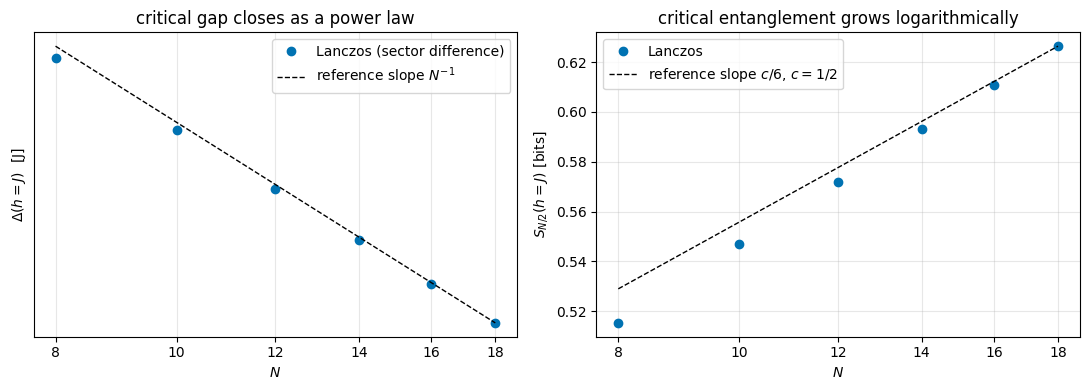

In [21]:
# ==============================================================================
# EXPERIMENT 4: critical point h = J, sizes up to N = 18
# ==============================================================================
crit = {}
t_start = time.time()
for N in (8, 10, 12, 14, 16, 18):
    if N in results:                                           # reuse the sweep
        crit[N] = (results[N]["gap"][i_c], results[N]["S"][i_c], results[N]["E0"][i_c])
        continue
    v_rand = haar_state(jax.random.PRNGKey(100 + N), N)
    solver = make_tfim_solver(N, m_krylov)
    even, odd = solver(1.0, project_parity(v_rand, +1)), solver(1.0, project_parity(v_rand, -1))
    crit[N] = (float(odd["E0"] - even["E0"]), float(even["S"]), float(even["E0"]))
    print(f"N={N}: done, residuals {float(even['res']):.1e} / {float(odd['res']):.1e}   [{time.time() - t_start:.0f} s]")

Ns_c = np.array(sorted(crit))
gaps_c = np.array([crit[N][0] for N in Ns_c])
S_c = np.array([crit[N][1] for N in Ns_c])
print("\n   N    gap (Lanczos)    gap (exact)     E0 error     S_half [bits]")
for N in Ns_c:
    E_ff, gap_ff = tfim_free_fermion(N, 1.0, 1.0)
    print(f"  {N:2d}    {crit[N][0]:.10f}    {gap_ff:.10f}    {abs(crit[N][2] - E_ff):.1e}      {crit[N][1]:.5f}")
    assert abs(crit[N][0] - gap_ff) < 1e5 * TOL

slope_gap = np.polyfit(np.log(Ns_c[-3:]), np.log(gaps_c[-3:]), 1)[0]
slope_S = np.polyfit(np.log2(Ns_c[-3:]), S_c[-3:], 1)[0]
print(f"\nfit over N = {Ns_c[-3:]}:  gap ~ N^({slope_gap:.3f})   (CFT: -1);   dS/dlog2(N) = {slope_S:.4f}   (CFT: c/6 = {1/12:.4f})")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.loglog(Ns_c, gaps_c, "o", label="Lanczos (sector difference)")
axL.loglog(Ns_c, gaps_c[-1] * Ns_c[-1] / Ns_c, "k--", lw=1, label=r"reference slope $N^{-1}$")
axL.set_xlabel("$N$"); axL.set_ylabel(r"$\Delta(h=J)$  [J]"); axL.set_title("critical gap closes as a power law")
axL.set_xticks(Ns_c); axL.set_xticklabels(Ns_c); axL.minorticks_off(); axL.legend()
axR.semilogx(Ns_c, S_c, "o", label="Lanczos")
axR.semilogx(Ns_c, S_c[-1] + (np.log2(Ns_c) - np.log2(Ns_c[-1])) / 12, "k--", lw=1, label=r"reference slope $c/6$, $c=1/2$")
axR.set_xlabel("$N$"); axR.set_ylabel(r"$S_{N/2}(h=J)$ [bits]"); axR.set_title("critical entanglement grows logarithmically")
axR.set_xticks(Ns_c); axR.set_xticklabels(Ns_c); axR.minorticks_off(); axR.legend()
plt.tight_layout(); plt.show()

The critical gap follows a power law with an exponent close to $-1$ (the small deviation is a finite-size correction: for the open chain the exact gap is $4J\sin\frac{\pi}{2(2N+1)}\approx \pi J/(N+\tfrac12)$, which is $1/N$ only
asymptotically), and the entropy grows linearly in $\log N$ with a slope near $c/6=0.083$; the measured slope is slightly larger because subleading corrections are still visible at $N\le18$. Two lessons: (i) the numbers a
laptop can reach are large enough to *see* critical scaling; (ii) they are not large enough to extract exponents to three digits — honest finite-size analysis needs either bigger systems
([matrix product states](../ch07_tensor_networks/18_mps_tebd.ipynb)) or knowledge of the corrections.

## 12. Physics II: the XXZ chain

### 12.1 Phases and an exact benchmark

The antiferromagnetic XXZ chain $H=J\sum_i(X_iX_{i+1}+Y_iY_{i+1}+\Delta Z_iZ_{i+1})$, $J>0$, has three regimes as a function of the anisotropy (not to be confused with the gap!) $\Delta$:

| $\Delta<-1$ | $-1<\Delta\le1$ | $\Delta>1$ |
|---|---|---|
| ferromagnet: all spins parallel, product state | **critical "XY" phase**: gapless, power-law correlations, no long-range order | **Néel antiferromagnet**: staggered order $\uparrow\downarrow\uparrow\downarrow$, gapped |

The model is solvable by the Bethe ansatz. For the Heisenberg point $\Delta=1$ Hulthén (1938) found the ground-state energy per site of the infinite chain, $e_\infty=J(\tfrac14-\ln2)$ in spin-operator units, i.e.

$$ e_\infty=(1-4\ln2)\,J=-1.772589\,J \qquad\text{(Pauli convention: } \vec\sigma_i\cdot\vec\sigma_j=4\,\vec S_i\cdot\vec S_j). $$

At $\Delta=0$ the model reduces to free fermions hopping on a ring, and for $N$ a multiple of 4 the ground-state energy of the periodic chain is $E_0=-4J/\sin(\pi/N)$ (each of the $N/2$ filled levels contributes $-4J\cos k$).
We use periodic chains here — they have no edges, hence smaller finite-size effects in bulk quantities — and work in the sector $M=\sum_iZ_i=0$, where the antiferromagnetic ground state lives.

In [22]:
# ==============================================================================
# EXPERIMENT 5: XXZ rings -- energies vs exact results, N = 8, 12, 16
# ==============================================================================
def make_xxz_solver(N, m):
    """Jitted (Delta, v0) -> ground-state properties of the periodic XXZ chain (J = 1)."""
    bonds = chain_bonds(N, periodic=True)

    def solve(Delta, v0):
        terms = xxz_terms(N, 1.0, Delta, bonds=bonds)
        E0, psi, res = ground_state_scan(terms, v0, m)
        czz = jnp.stack([expect_local(psi, ZZ, [0, r]) for r in range(1, N // 2 + 1)])     # <Z_0 Z_r>
        cxx = expect_local(psi, XX, [0, 1])
        S_half = entanglement_entropy(psi, range(N // 2))
        M = jnp.real(jnp.vdot(psi, apply_magnetisation(psi)))
        return {"E0": E0, "res": res, "czz": czz, "cxx": cxx, "S": S_half, "M": M}
    return jax.jit(solve)


m_xxz = 80
xxz = {}
t_start = time.time()
for N in (8, 12, 16):
    v0 = project_magnetisation(haar_state(jax.random.PRNGKey(200 + N), N), M0=0)     # random state with M = 0
    solver = make_xxz_solver(N, m_xxz)
    xxz[N] = {D: {k: np.asarray(v) for k, v in solver(D, v0).items()} for D in (0.0, 1.0, 2.0)}
    print(f"N={N:2d}  [{time.time() - t_start:.0f} s]   residuals: " + ", ".join(f"Delta={D}: {xxz[N][D]['res']:.1e}" for D in xxz[N])
          + f"   <M> = {max(abs(xxz[N][D]['M']) for D in xxz[N]):.1e}")

print("\nDelta = 0 (free fermions):")
for N in xxz:
    exact = -4.0 / np.sin(np.pi / N)
    print(f"  N={N:2d}: E0 = {xxz[N][0.0]['E0']:.10f}   exact -4/sin(pi/N) = {exact:.10f}   error = {abs(xxz[N][0.0]['E0'] - exact):.1e}")
    assert abs(xxz[N][0.0]["E0"] - exact) < 1e4 * TOL

print("\nDelta = 1 (Heisenberg): energy per site vs Bethe ansatz")
e_inf = 1 - 4 * np.log(2)
eN = np.array([xxz[N][1.0]["E0"] / N for N in xxz])
for N, e in zip(xxz, eN):
    print(f"  N={N:2d}: E0/N = {e:.8f}   (E0/N - e_inf) * N^2 = {(e - e_inf) * N**2:.4f}")
coef = np.polyfit(1.0 / np.array(list(xxz)) [1:] ** 2, eN[1:], 1)          # linear in 1/N^2 through N = 12, 16
print(f"  extrapolation linear in 1/N^2 through N=12,16:  e_inf = {coef[1]:.6f}     Bethe ansatz: {e_inf:.6f}     difference {abs(coef[1] - e_inf):.1e}")

N= 8  [1 s]   residuals: Delta=0.0: 5.6e-15, Delta=1.0: 9.7e-15, Delta=2.0: 1.3e-14   <M> = 2.3e-18


N=12  [2 s]   residuals: Delta=0.0: 1.5e-14, Delta=1.0: 1.7e-14, Delta=2.0: 2.7e-14   <M> = 1.6e-18


N=16  [8 s]   residuals: Delta=0.0: 1.9e-14, Delta=1.0: 2.4e-14, Delta=2.0: 2.8e-14   <M> = 8.2e-19

Delta = 0 (free fermions):
  N= 8: E0 = -10.4525037190   exact -4/sin(pi/N) = -10.4525037190   error = 0.0e+00
  N=12: E0 = -15.4548132206   exact -4/sin(pi/N) = -15.4548132206   error = 7.1e-15
  N=16: E0 = -20.5033235819   exact -4/sin(pi/N) = -20.5033235819   error = 7.1e-15

Delta = 1 (Heisenberg): energy per site vs Bethe ansatz
  N= 8: E0/N = -1.82554670   (E0/N - e_inf) * N^2 = -3.3893
  N=12: E0/N = -1.79579697   (E0/N - e_inf) * N^2 = -3.3420
  N=16: E0/N = -1.78557409   (E0/N - e_inf) * N^2 = -3.3243
  extrapolation linear in 1/N^2 through N=12,16:  e_inf = -1.772430     Bethe ansatz: -1.772589     difference 1.6e-04


* At $\Delta=0$ the Lanczos energies agree with the free-fermion formula to round-off — a checkpoint at $N=16$ that needs no dense matrix.
* At $\Delta=1$ the energy per site approaches the Bethe-ansatz value from below, and $(e_N-e_\infty)N^2$ is nearly constant: the leading finite-size correction of a critical periodic chain is $\propto1/N^2$ (its coefficient
  is again fixed by conformal field theory, up to logarithmic corrections specific to the Heisenberg point). A two-point extrapolation in $1/N^2$ reproduces Hulthén's number to about three digits.
* The conserved magnetisation $\langle M\rangle$ of the final states is zero to round-off, as it must be for a Krylov space grown from an $M=0$ vector.

### 12.2 Spin correlations across the phases

The staggered correlation function $(-1)^r\langle Z_0Z_r\rangle$ distinguishes the phases: it decays as a power law in the critical phase and saturates to a constant in the Néel phase.

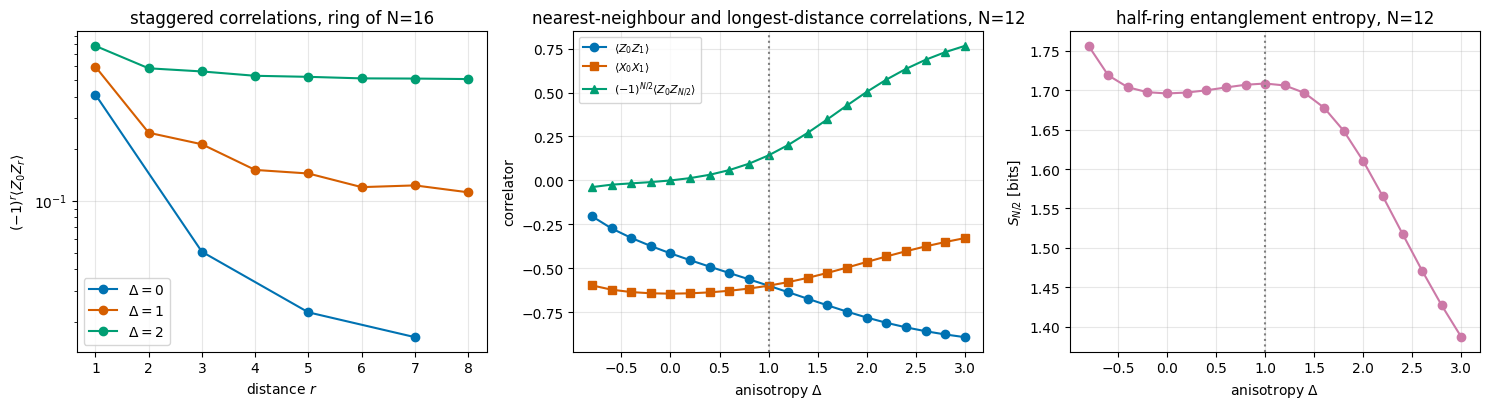

sweep: max residual = 3.8e-14,  max |<M>| = 3.3e-18
Delta = 1.00: <Z0Z1> = -0.59860, <X0X1> = -0.59860
N=16, r=8: staggered correlation = -0.0000 (Delta=0), 0.1117 (Delta=1), 0.5046 (Delta=2)


In [23]:
# ==============================================================================
# FIGURE: staggered spin correlations of the N=16 XXZ ring, and an anisotropy sweep at N=12
# ==============================================================================
fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(15, 4.2))
r_vals = np.arange(1, 9)
for c, D in zip(CB, (0.0, 1.0, 2.0)):
    stag_corr = (-1.0) ** r_vals * xxz[16][D]["czz"]
    keep = stag_corr > 1e-10                                     # exact zeros (Delta=0, even r) cannot be shown on a log axis
    axL.plot(r_vals[keep], stag_corr[keep], "o-", color=c, label=rf"$\Delta={D:g}$")
axL.set_xlabel("distance $r$"); axL.set_ylabel(r"$(-1)^r\langle Z_0Z_r\rangle$"); axL.set_yscale("log")
axL.set_title("staggered correlations, ring of N=16"); axL.legend()

# anisotropy sweep with vmap at N = 12 (cheap): 20 values of Delta in one batched call
Deltas = jnp.linspace(-0.8, 3.0, 20)
N_sw = 12
v0_sw = project_magnetisation(haar_state(jax.random.PRNGKey(212), N_sw), M0=0)
sweep = jax.vmap(make_xxz_solver(N_sw, m_xxz), in_axes=(0, None))(Deltas, v0_sw)
sweep = {k: np.asarray(v) for k, v in sweep.items()}
stag = np.array([(-1.0) ** (N_sw // 2) * sweep["czz"][i, -1] for i in range(len(Deltas))])      # longest distance r = N/2
axM.plot(Deltas, sweep["czz"][:, 0], "o-", label=r"$\langle Z_0Z_1\rangle$")
axM.plot(Deltas, sweep["cxx"], "s-", label=r"$\langle X_0X_1\rangle$")
axM.plot(Deltas, stag, "^-", label=r"$(-1)^{N/2}\langle Z_0Z_{N/2}\rangle$")
axM.axvline(1.0, color="gray", ls=":"); axM.set_xlabel(r"anisotropy $\Delta$"); axM.set_ylabel("correlator")
axM.set_title(f"nearest-neighbour and longest-distance correlations, N={N_sw}"); axM.legend(fontsize=8)
axR.plot(Deltas, sweep["S"], "o-", color=CB[3])
axR.axvline(1.0, color="gray", ls=":"); axR.set_xlabel(r"anisotropy $\Delta$"); axR.set_ylabel(r"$S_{N/2}$ [bits]")
axR.set_title(f"half-ring entanglement entropy, N={N_sw}")
plt.tight_layout(); plt.show()
print(f"sweep: max residual = {sweep['res'].max():.1e},  max |<M>| = {np.abs(sweep['M']).max():.1e}")
i1 = int(np.argmin(np.abs(np.asarray(Deltas) - 1.0)))
print(f"Delta = {float(Deltas[i1]):.2f}: <Z0Z1> = {sweep['czz'][i1, 0]:.5f}, <X0X1> = {sweep['cxx'][i1]:.5f}")
print(f"N=16, r=8: staggered correlation = {xxz[16][0.0]['czz'][-1]:.4f} (Delta=0), {xxz[16][1.0]['czz'][-1]:.4f} (Delta=1), {xxz[16][2.0]['czz'][-1]:.4f} (Delta=2)")

* *Left:* all correlations are antiferromagnetic (positive after multiplication with $(-1)^r$). For $\Delta=0$ and $1$ they keep decaying with distance — the hallmark of the critical phase (at $\Delta=0$ free-fermion theory gives
  $\propto1/r^2$ for odd $r$ and exactly zero for even $r$, which is why only odd distances appear on the logarithmic axis); for $\Delta=2$ they level off at a finite value: long-range **Néel order**.
* *Middle:* as $\Delta$ grows, antiferromagnetic $zz$ correlations strengthen at the expense of $xx$ correlations. The two nearest-neighbour curves **cross at $\Delta=1$**, where the Hamiltonian is rotationally invariant and the
  singlet ground state cannot distinguish $x$ from $z$ (the printed numbers at the grid point closest to $\Delta=1$ are nearly equal). The longest-distance correlator rises steeply beyond $\Delta\approx1$.
* *Right:* the entanglement entropy is largest in the critical region and drops once the Néel gap opens — for large $\Delta$ it approaches 1 bit, the entropy of the cat state
  $(|\!\uparrow\downarrow\uparrow\downarrow\cdots\rangle+|\!\downarrow\uparrow\downarrow\uparrow\cdots\rangle)/\sqrt2$, in complete analogy with the Ising ferromagnet.

> **Physics insight.** Unlike the Ising transition, the transition at $\Delta=1$ is of Berezinskii–Kosterlitz–Thouless type: the Néel gap does not open linearly in $\Delta-1$ but exponentially slowly. Writing
> $\Delta=\cosh\lambda$, the Bethe-ansatz result (des Cloizeaux & Gaudin 1966) is $\Delta_{\rm gap}\to4\pi J\,e^{-\pi^2/(2\lambda)}$ as $\lambda\to0$, and with $\lambda\approx\sqrt{2(\Delta-1)}$ this is
> $\Delta_{\rm gap}\sim e^{-\pi^2/\sqrt{8(\Delta-1)}}$. At $\Delta=1.1$ that exponent is already $-11$: the gap is $\sim10^{-4}J$, far below the finite-size level spacing of any chain we can diagonalise. This is why
> finite-size data change very smoothly across $\Delta=1$ and why locating a BKT transition from small systems is notoriously hard.

### 12.3 The XXZ chain in a transverse field: the questions exact diagonalisation left open

[Notebook 06, Section 10](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) mapped the ground-state phase diagram of the open chain

$$ H(\Delta,h_x)=\sum_{i=0}^{N-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\big)+h_x\sum_{i=0}^{N-1}X_i $$

by dense diagonalisation in the two sectors of the spin flip $P=\prod_iX_i$, and it ended with open questions: with $N\le12$ it could not decide whether the gap
inside the ground-state sector stays finite on the Néel side $(\Delta,h_x)=(2,0)$ and in the field $(0,1)$, and the field-induced antiferromagnetic order along $y$ was only suggested
by one chain length. Lanczos in a parity sector reaches $N=18$ at the same cost per point as a dense run at $N=12$. Three tools of this notebook combine:

* the **start vector is projected** onto the sector $P=\pm1$, and the projector is applied again after every $H|v\rangle$ (Section 10.2), so that round-off cannot leak into the other sector;
* the **gap within the sector** is the difference of the two lowest Ritz values $\theta_1-\theta_0$ of *one* run. This is legitimate only with full reorthogonalisation (no ghosts, Section 7)
  and only once *both* Ritz pairs have converged, which we check with their residuals (Section 8.2);
* the couplings enter `spin_hamiltonian_terms` as traced values, so one compiled solver per $N$ serves all parameter points and both sectors.

We record, at the four points of notebook 06 and at $(0,2)$, where the $y$ correlations were largest: the gap in the ground-state sector, the splitting between the lowest levels of the two
sectors, and the staggered correlation $C^{yy}_{\rm st}=(-1)^r\langle Y_iY_j\rangle$ between the sites $i=\lfloor N/4\rfloor$ and $j=N-1-i$, the largest distance that keeps both spins a quarter
of the chain away from the ends.

In [24]:
# ==============================================================================
# EXPERIMENT 5b: the XXZ chain in a transverse field in its parity sectors, N = 6 ... 18
# ==============================================================================
def make_xxz_field_solver(N, m):
    """Jitted (Delta, hx, sign, v0) -> two lowest Ritz values of the parity sector P = sign, their residuals, and the ground Ritz vector.

    MATH      Lanczos for  Pi H Pi,  Pi = (1 + sign P)/2  (Section 10);  gap in the sector = theta_1 - theta_0;  residual rho_k = ||H x_k - theta_k x_k||.
    JAX       Delta, hx and sign are traced -> ONE compilation per N serves every parameter point and both sectors.
    """
    bonds = chain_bonds(N)

    def solve(Delta, hx, sign, v0):
        terms = spin_hamiltonian_terms(N, bonds, J=(1.0, 1.0, Delta), h=(hx, 0.0, 0.0))
        project = lambda p: 0.5 * (p + sign * apply_parity(p))
        matvec = lambda p: project(apply_hamiltonian(terms, p))            # the projector after every H|v>: no leak into the other sector
        alphas, betas, V = lanczos_scan(matvec, project(v0), m)
        theta, S = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas, 1) + jnp.diag(betas, -1))
        x0, x1 = ((S[:, k].astype(V.dtype) @ V).reshape(v0.shape) for k in (0, 1))
        res = jnp.stack([jnp.linalg.norm(matvec(x) - th * x) for x, th in ((x0, theta[0]), (x1, theta[1]))])
        return theta[:2], res, x0
    return jax.jit(solve)


# ------------------------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------------------------
POINTS_XF = {"critical (0, 0)": (0.0, 0.0), "field (0, 1)": (0.0, 1.0), "ferro (-2, 0)": (-2.0, 0.0),
             "Neel side (2, 0)": (2.0, 0.0), "y order? (0, 2)": (0.0, 2.0)}
N_XF = (6, 8, 10, 12, 14, 16, 18)        # N = 18: sectors of dimension 131 072, Krylov basis m * 2^N * 16 B = 0.5 GB
m_xf = 120

xf = {}
t_start = time.time()
for N in N_XF:
    solve = make_xxz_field_solver(N, m_xf)
    v0 = haar_state(jax.random.PRNGKey(300 + N), N)
    i_c, j_c = N // 4, N - 1 - N // 4
    for label, (D, h) in POINTS_XF.items():
        runs = {s: solve(D, h, float(s), v0) for s in (+1, -1)}
        s0 = min(runs, key=lambda s: float(runs[s][0][0]))                 # the sector of the ground state
        theta, res, psi = runs[s0]
        xf[(label, N)] = {"E0": float(theta[0]), "gap": float(theta[1] - theta[0]), "res": np.asarray(res),
                          "split": abs(float(runs[+1][0][0] - runs[-1][0][0])),
                          "cyy": (-1) ** (j_c - i_c) * float(expect_local(psi, YY, [i_c, j_c])), "r": j_c - i_c,
                          "S": float(entanglement_entropy(psi, range(N // 2)))}
    print(f"N={N:2d} done  [{time.time() - t_start:.0f} s]   largest residual of the two Ritz pairs: "
          f"{max(xf[(l, N)]['res'].max() for l in POINTS_XF):.1e}")

# ------------------------------------------------------------------------------
# CHECKPOINTS: the exact XX gap at every N (notebook 06, Eq. (14)), and dense diagonalisation inside the sectors at N = 10
# ------------------------------------------------------------------------------
for N in N_XF:
    exact = 4 * np.sin(np.pi / (2 * (N + 1)))
    assert abs(xf[("critical (0, 0)", N)]["gap"] - exact) < 1e4 * TOL, (N, xf[("critical (0, 0)", N)]["gap"], exact)
print("XX chain: gap in the sector = 4 sin(pi / 2(N+1)) for every N  (max deviation "
      f"{max(abs(xf[('critical (0, 0)', N)]['gap'] - 4 * np.sin(np.pi / (2 * (N + 1)))) for N in N_XF):.1e})")
D10, idx10 = 2 ** 10, np.arange(2 ** 9)
for label, (D, h) in POINTS_XF.items():
    H10 = np.real(np.asarray(dense_hamiltonian(heisenberg_terms(10, 1.0, 1.0, D, hx=h), 10)))
    w_sec = {}
    for s in (+1, -1):                                                      # sector bases |i,+-> of notebook 06, Eq. (15)
        B = np.zeros((D10, D10 // 2)); B[idx10, idx10] = 1 / np.sqrt(2); B[D10 - 1 - idx10, idx10] = s / np.sqrt(2)
        w_sec[s] = np.linalg.eigvalsh(B.T @ H10 @ B)
    s0 = min(w_sec, key=lambda s: w_sec[s][0])
    err = abs(w_sec[s0][1] - w_sec[s0][0] - xf[(label, 10)]["gap"])
    print(f"N=10 {label:17s}: gap in the sector, Lanczos {xf[(label, 10)]['gap']:.8f} | dense {w_sec[s0][1] - w_sec[s0][0]:.8f} | diff {err:.1e}")
    assert err < 1e4 * TOL

print("\n  point              N:  " + "  ".join(f"{N:>7d}" for N in N_XF))
for label in POINTS_XF:
    print(f"  {label:17s} gap   " + "  ".join(f"{xf[(label, N)]['gap']:7.4f}" for N in N_XF))
    print(f"  {'':17s} split " + "  ".join(f"{xf[(label, N)]['split']:7.1e}" for N in N_XF))
    print(f"  {'':17s} C^yy  " + "  ".join(f"{xf[(label, N)]['cyy']:+7.4f}" for N in N_XF))
print("  distance r        " + "  ".join(f"{xf[('field (0, 1)', N)]['r']:7d}" for N in N_XF))

N= 6 done  [1 s]   largest residual of the two Ritz pairs: 1.1e-14


N= 8 done  [2 s]   largest residual of the two Ritz pairs: 2.0e-14


N=10 done  [3 s]   largest residual of the two Ritz pairs: 1.9e-14


N=12 done  [5 s]   largest residual of the two Ritz pairs: 5.4e-11


N=14 done  [16 s]   largest residual of the two Ritz pairs: 4.5e-09


...

N=10 critical (0, 0)  : gap in the sector, Lanczos 0.56925935 | dense 0.56925935 | diff 7.1e-15


N=10 field (0, 1)     : gap in the sector, Lanczos 1.06981307 | dense 1.06981307 | diff 1.0e-13


N=10 ferro (-2, 0)    : gap in the sector, Lanczos 2.99565809 | dense 2.99565809 | diff 5.5e-14


N=10 Neel side (2, 0) : gap in the sector, Lanczos 2.24855143 | dense 2.24855143 | diff 1.7e-13


N=10 y order? (0, 2)  : gap in the sector, Lanczos 0.94933144 | dense 0.94933144 | diff 1.4e-14

  point              N:        6        8       10       12       14       16       18
  critical (0, 0)   gap    0.8901   0.6946   0.5693   0.4821   0.4181   0.3691   0.3303
                    split 8.9e-01  6.9e-01  5.7e-01  4.8e-01  4.2e-01  3.7e-01  3.3e-01
                    C^yy  +0.2366  +0.3971  +0.2876  +0.2132  +0.1744  +0.2310  +0.1971
  field (0, 1)      gap    1.5272   1.2619   1.0698   0.9293   0.8243   0.7443   0.6830
                    split 3.8e-01  5.1e-01  5.1e-01  4.2e-01  2.9e-01  1.7e-01  6.6e-02
                    C^yy  +0.4069  +0.2853  +0.2188  +0.3328  +0.2829  +0.2416  +0.2408
  ferro (-2, 0)     gap    2.9358   2.9830   2.9957   2.9989   2.9997   2.9999   3.0000
                    split 1.8e-15  0.0e+00  1.4e-14  1.4e-14  2.1e-14  3.6e-15  3.6e-14
                    C^yy  -0.0000  -0.0000  -0.0000  +0.0000  -0.0000  -0.0000  -0.0000
  Neel side (2, 0)  gap 

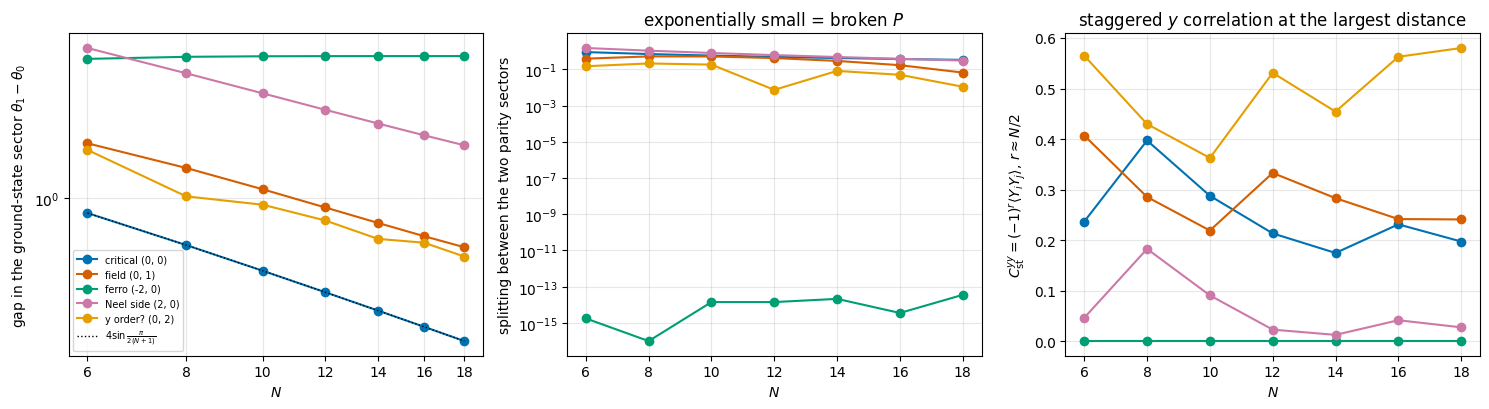

In [25]:
# ==============================================================================
# FIGURE: gap in the sector, parity splitting and staggered y correlation against N
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Ns = np.array(N_XF)
for c, label in zip(CB, POINTS_XF):
    axes[0].loglog(Ns, [xf[(label, N)]["gap"] for N in N_XF], "o-", color=c, label=label)
    axes[1].semilogy(Ns, [max(xf[(label, N)]["split"], 1e-16) for N in N_XF], "o-", color=c, label=label)
    axes[2].plot(Ns, [xf[(label, N)]["cyy"] for N in N_XF], "o-", color=c, label=label)
axes[0].loglog(Ns, 4 * np.sin(np.pi / (2 * (Ns + 1))), "k:", lw=1, label=r"$4\sin\frac{\pi}{2(N+1)}$")
axes[0].set_xticks(Ns); axes[0].set_xticklabels(Ns); axes[0].minorticks_off()
axes[0].set_xlabel("$N$"); axes[0].set_ylabel(r"gap in the ground-state sector $\theta_1-\theta_0$"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("$N$"); axes[1].set_ylabel("splitting between the two parity sectors"); axes[1].set_title("exponentially small = broken $P$")
axes[2].set_xlabel("$N$"); axes[2].set_ylabel(r"$C^{yy}_{\rm st}=(-1)^r\langle Y_iY_j\rangle$, $r\approx N/2$"); axes[2].set_title("staggered $y$ correlation at the largest distance")
plt.tight_layout(); plt.show()

**What the larger chains tell** (numbers printed above).

* **Checkpoints.** At the XX point the gap in the sector equals $4\sin\frac{\pi}{2(N+1)}$ for every $N$ up to $18$, and at $N=10$ all five gaps agree with dense diagonalisation inside the sectors.
  The residuals of both Ritz pairs stay below $10^{-8}$ except for the second pair at $N=18$ in two places. At the ferromagnetic point the second Ritz value belongs to a pair of magnons
  bound to the two ends of the chain (notebook 06, Eq. (16)): the two levels are split only by $\sim3\times10^{-5}$ at $N=18$, the relative gap $\gamma$ of Eq. (6) is tiny, and the residual of
  $\theta_1$ stops at $\sim6\times10^{-5}$. The gap value $\approx2.99998$ is still accurate to about that level — the rule "energies to $\rho^2/\Delta$" of Section 8.2 with a $\Delta$ that is itself $10^{-5}$.
  At $(0,2)$ the residual of $\theta_1$ is $1.3\times10^{-4}$, so that gap is known to about four digits — enough for the conclusions below.
* **The field at $\Delta=0$, $h_x=1$.** The gap in the sector decreases from $1.53$ ($N=6$) to $0.68$ ($N=18$), but *more slowly than $1/N$*: $N\Delta_N$ keeps growing, and the ratio to the
  gapless XX chain rises from $1.7$ to $2.1$. At the same time the splitting between the two parity sectors, of order one up to $N=12$, collapses to $0.07$ at $N=18$, and the staggered
  $y$ correlation stays near $0.24$ out to distance $9$. Both are the fingerprints of the prediction of Dmitriev, Krivnov and Ovchinnikov (2002): the field opens a gap and the ground state
  orders antiferromagnetically along $y$, which breaks $P$ (the operator $P=\prod_iX_i$ reverses every $Y_i$), so the two sector ground states become a near-degenerate doublet.
  Eighteen spins make this strongly suggestive; a proof needs the extrapolation of the splitting and of $C^{yy}_{\rm st}$ to $N\to\infty$.
* **Deep in the field-induced phase, $(0,2)$.** $C^{yy}_{\rm st}$ at the largest distance stays between $0.45$ and $0.58$ for all sizes — it does not decay with distance — and the parity splitting
  is small at every $N$ (it jumps up and down because levels of the two sectors cross as $N$ changes). This is the clearest case of long-range $y$ order in the scan.
* **The Néel side, $(2,0)$.** The gap still decreases at $N=18$ ($3.19\to1.50$), and the parity splitting shrinks only slowly ($1.50\to0.30$). The Néel gap of the XXZ chain opens
  exponentially slowly above $\Delta=1$ (Section 12.2), so the correlation length at $\Delta=2$ is still comparable to our chains: $N\le18$ cannot decide this point either, and it is the natural
  test case for the matrix-product states of Chapter 7.

> **Numerical practice.** One Lanczos run with full reorthogonalisation gave two levels at once, and the residual of the *second* Ritz pair told us when that second level could be trusted.
> Always print the residuals of every eigenvalue you use, not only of the ground state.

## 13. Beyond chains: a square lattice and long-range interactions

Nothing in our solver referred to one dimension. We now change **only the bond list**:

* a $4\times4$ open square lattice (24 bonds, 16 spins). Each bulk spin now has four neighbours, so the ferromagnetic term is stronger relative to the field and the transition moves to a larger field. For the infinite
  square lattice quantum Monte Carlo gives $h_c\approx3.044\,J$ (Blöte & Deng 2002); the model is *not* exactly solvable, so there is no free-fermion check — we rely on the validation of the builder in Section 3, on the ladder test of
  Section 8 and on the residual;
* an open chain of $N=12$ spins with ferromagnetic power-law couplings $-J\,Z_iZ_j/|i-j|^\alpha$ as realised with trapped ions (66 bonds). Longer-range couplings stabilise the ferromagnet against the field.

In both cases the relevant control parameter is the **total coupling seen by one spin**, $\bar w=\frac{2}{N}\sum_{i<j}w_{ij}$, which plays the role of the coordination number $z$ of a uniform lattice. Mean-field theory for the
TFIM (replace $Z_j$ by $\langle Z\rangle$ in every bond) puts the transition at $h_c^{\rm MF}=zJ$; the exact answers, $h_c=J$ for the chain ($z=2$) and $h_c=3.044J$ for the square lattice ($z=4$), are $0.50$ and $0.76$ of that,
the difference being quantum fluctuations, which are weaker in higher dimension. Keep this in mind when reading the figure: the curves below are not compared at fixed energy scale.

4x4 grid : 24 bonds, max residual = 4.1e-13   [12 s]


alpha=1.5: 66 bonds, max residual = 3.8e-14


alpha=3.0: 66 bonds, max residual = 6.7e-14


long-range check (N=10, alpha=1.5, h=1.5J): |E0 - dense| = 7.1e-15, residual = 2.3e-14


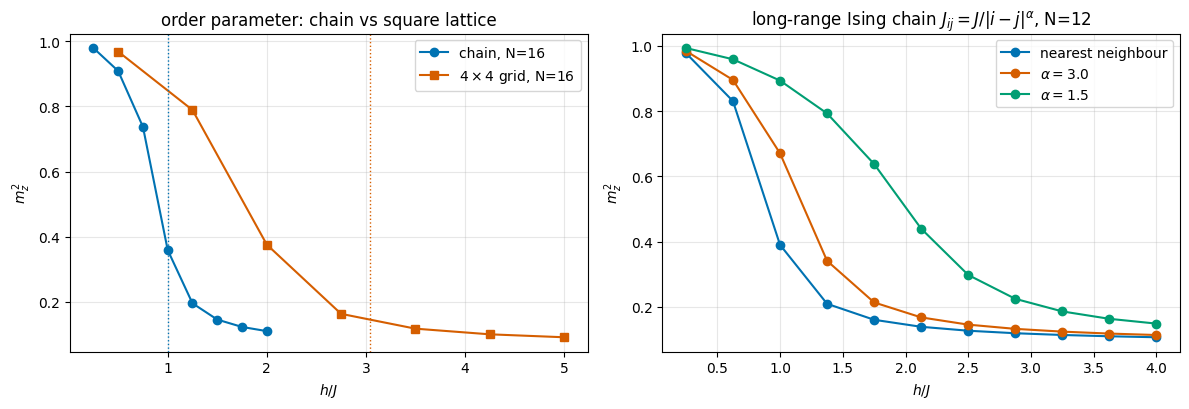

field at which m_z^2 drops to 1/2:  chain 0.91 J,  4x4 grid 1.77 J

mean coupling per spin  w_bar = (2/N) sum_{i<j} w_ij,  and the crossover field it goes with:
   nearest neighbour (N=12): w_bar = 1.833   h(m_z^2=1/2) = 0.91 J
   alpha = 3.0            : w_bar = 2.137   h(m_z^2=1/2) = 1.19 J   (ratios to nearest neighbour: w_bar 1.17, field 1.32)
   alpha = 1.5            : w_bar = 3.158   h(m_z^2=1/2) = 2.01 J   (ratios to nearest neighbour: w_bar 1.72, field 2.22)


In [26]:
# ==============================================================================
# EXPERIMENT 6: TFIM on a 4x4 grid (N=16) and on long-range chains (N=12)
# ==============================================================================
hs_2d = np.arange(0.5, 5.01, 0.75)
t_start = time.time()
v_grid = project_parity(haar_state(jax.random.PRNGKey(44), 16), +1)
solver_grid = make_tfim_solver(16, m_krylov, bonds=grid_bonds(4, 4))
runs = [solver_grid(h, v_grid) for h in hs_2d]
grid = {k: np.asarray(jnp.stack([r[k] for r in runs])) for k in runs[0]}
print(f"4x4 grid : {len(grid_bonds(4, 4))} bonds, max residual = {grid['res'].max():.1e}   [{time.time() - t_start:.0f} s]")

hs_lr = jnp.linspace(0.25, 4.0, 11)
N_lr = 12
v_lr = project_parity(haar_state(jax.random.PRNGKey(45), N_lr), +1)
long_range = {}
for alpha in (1.5, 3.0):
    bonds_lr, weights_lr = long_range_bonds(N_lr, alpha)
    out = jax.vmap(make_tfim_solver(N_lr, m_krylov, bonds=bonds_lr, weights=weights_lr), in_axes=(0, None))(hs_lr, v_lr)
    long_range[alpha] = {k: np.asarray(v) for k, v in out.items()}
    print(f"alpha={alpha}: {len(bonds_lr)} bonds, max residual = {long_range[alpha]['res'].max():.1e}")
out = jax.vmap(make_tfim_solver(N_lr, m_krylov), in_axes=(0, None))(hs_lr, v_lr)
long_range[np.inf] = {k: np.asarray(v) for k, v in out.items()}

# dense validation of the long-range solver at one point (N=10: 1024 x 1024, validation only)
bonds_v, weights_v = long_range_bonds(10, 1.5)
terms_v = tfim_terms(10, 1.0, 1.5, bonds=bonds_v, weights=weights_v)
E_lr, _, res_lr = jax.jit(lambda v: ground_state_scan(terms_v, v, m_krylov))(project_parity(haar_state(jax.random.PRNGKey(46), 10), +1))
E_dense_lr = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_v, 10)))[0]
print(f"long-range check (N=10, alpha=1.5, h=1.5J): |E0 - dense| = {abs(float(E_lr) - E_dense_lr):.1e}, residual = {float(res_lr):.1e}")
assert abs(float(E_lr) - E_dense_lr) < 1e4 * TOL

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
axL.plot(hs, results[16]["mz2"], "o-", label="chain, N=16")
axL.plot(hs_2d, grid["mz2"], "s-", label=r"$4\times4$ grid, N=16")
axL.axvline(1.0, color=CB[0], ls=":", lw=1); axL.axvline(3.044, color=CB[1], ls=":", lw=1)
axL.set_xlabel("$h/J$"); axL.set_ylabel(r"$m_z^2$"); axL.set_title("order parameter: chain vs square lattice"); axL.legend()
for c, alpha in zip(CB, (np.inf, 3.0, 1.5)):
    lab = "nearest neighbour" if np.isinf(alpha) else rf"$\alpha={alpha}$"
    axR.plot(hs_lr, long_range[alpha]["mz2"], "o-", color=c, label=lab)
axR.set_xlabel("$h/J$"); axR.set_ylabel(r"$m_z^2$"); axR.set_title(rf"long-range Ising chain $J_{{ij}}=J/|i-j|^\alpha$, N={N_lr}"); axR.legend()
plt.tight_layout(); plt.show()
h_half_chain = np.interp(0.5, results[16]["mz2"][::-1], hs[::-1])
h_half_grid = np.interp(0.5, grid["mz2"][::-1], hs_2d[::-1])
print(f"field at which m_z^2 drops to 1/2:  chain {h_half_chain:.2f} J,  4x4 grid {h_half_grid:.2f} J")
print("\nmean coupling per spin  w_bar = (2/N) sum_{i<j} w_ij,  and the crossover field it goes with:")
wbar_nn = 2 * (N_lr - 1) / N_lr
h_half_nn = float(np.interp(0.5, long_range[np.inf]["mz2"][::-1], np.asarray(hs_lr)[::-1]))
print(f"   nearest neighbour (N={N_lr}): w_bar = {wbar_nn:.3f}   h(m_z^2=1/2) = {h_half_nn:.2f} J")
for alpha in (3.0, 1.5):
    wbar = 2 * sum(long_range_bonds(N_lr, alpha)[1]) / N_lr
    h_half = float(np.interp(0.5, long_range[alpha]["mz2"][::-1], np.asarray(hs_lr)[::-1]))
    print(f"   alpha = {alpha}            : w_bar = {wbar:.3f}   h(m_z^2=1/2) = {h_half:.2f} J   "
          f"(ratios to nearest neighbour: w_bar {wbar / wbar_nn:.2f}, field {h_half / h_half_nn:.2f})")

With the *same solver* and a different list of bonds, the ordered phase of the square lattice survives to clearly larger fields than in the chain: the printed crossover field, where $m_z^2$ has dropped to $1/2$, moves
from $\approx0.9\,J$ to $\approx1.8\,J$, a factor of two. The dotted lines mark the thermodynamic-limit critical fields, $h_c=J$ for the chain and $h_c\approx3.04J$ for the infinite square lattice (Blöte & Deng 2002).
Our $4\times4$ patch sits well below the latter, for two reasons that both shrink the effective coupling: with open boundaries only four of its sixteen spins have the full four neighbours, so $\bar w=2\cdot24/16=3$ rather than
$4$ — mean field would already move $h_c$ down by a quarter — and the block is only four sites wide, so the order parameter has not yet saturated (the same finite-size drift that pulled the chain's crossover from $J$ to $0.91J$).

The long-range chains behave the same way, and the printed table separates the two contributions. Going from nearest-neighbour to $\alpha=3$ multiplies $\bar w$ by $1.17$ and the crossover field by $1.32$; going to
$\alpha=1.5$ multiplies them by $1.72$ and $2.22$. Most of the extra robustness of the long-range ferromagnet is therefore *not* a long-range effect at all, it is simply a larger total coupling per spin; what is left over
(factors $1.13$ and $1.29$) is the real one. A fair comparison at fixed energy scale uses the Kac rescaling $J\to J/\bar w$, which is also what keeps the energy extensive for $\alpha<1$. The genuinely long-range physics —
a changed universality class, correlations that never decay — needs larger systems than a state vector allows. What the experiment does show is that the *cost* is unchanged: the $\alpha$ runs touch $66$ bonds instead
of $11$ and are one line of code apart, whereas analytical solutions (and also matrix-product-state methods) are tied to one dimension and short-range couplings.

## 14. Performance: cost and reach

The cost model of Lanczos with full reorthogonalisation for a Hamiltonian with $N_t$ local terms is

$$ \text{time}\approx m\,\big[\underbrace{c_1N_t\,2^N}_{\text{matvec}}+\underbrace{c_2\,m\,2^N}_{\text{reorthogonalisation}}\big],\qquad \text{memory}\approx m\cdot2^N\cdot16\ \text{bytes}. $$

Both are **exponential in $N$ but linear in everything else** — compare with $8^N$ and $4^N$ for dense diagonalisation. We measure the time of one jitted $H|\psi\rangle$ for the TFIM chain and tabulate the memory of the Krylov basis.

   N     dim        matvec [ms]    Krylov basis (m=80) [MB]    dense H [MB]
   8        256          0.03                 0.3                      1.0


  10       1024          0.08                 1.3                     16.8
  12       4096          0.38                 5.2                    268.4


  14      16384          1.97                21.0                   4295.0


  16      65536         12.81                83.9                  68719.5


  18     262144         74.03               335.5                1099511.6


  20    1048576        199.90              1342.2               17592186.0


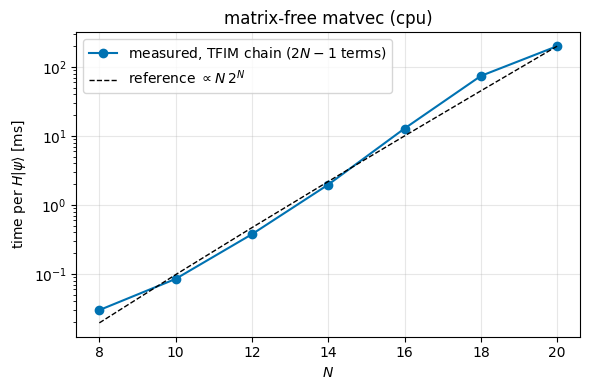

In [27]:
# ==============================================================================
# BENCHMARK: one matrix-free matvec vs N;  memory of the Krylov basis vs the dense matrix
# ==============================================================================
print("   N     dim        matvec [ms]    Krylov basis (m=80) [MB]    dense H [MB]")
bench_N, bench_t = [], []
for N in (8, 10, 12, 14, 16, 18, 20):
    terms_b = tfim_terms(N, 1.0, 1.0)
    mv = jax.jit(lambda p: apply_hamiltonian(terms_b, p))
    psi_b = haar_state(jax.random.PRNGKey(N), N)
    mv(psi_b).block_until_ready()                                # compile + warm up (not timed)
    reps = 20 if N <= 16 else 5
    t0 = time.time()
    for _ in range(reps):
        out = mv(psi_b)
    out.block_until_ready()                                      # JAX is asynchronous: wait before stopping the clock
    dt_ms = (time.time() - t0) / reps * 1e3
    bench_N.append(N); bench_t.append(dt_ms)
    print(f"  {N:2d}  {2**N:9d}     {dt_ms:9.2f}        {80 * 2**N * 16 / 1e6:12.1f}           {4.0**N * 16 / 1e6:14.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(bench_N, bench_t, "o-", label=r"measured, TFIM chain ($2N-1$ terms)")
ax.semilogy(bench_N, bench_t[-1] * np.array(bench_N) / bench_N[-1] * 2.0 ** (np.array(bench_N) - bench_N[-1]), "k--", lw=1, label=r"reference $\propto N\,2^N$")
ax.set_xlabel("$N$"); ax.set_ylabel(r"time per $H|\psi\rangle$ [ms]"); ax.set_title(f"matrix-free matvec ({jax.default_backend()})"); ax.legend()
plt.tight_layout(); plt.show()

For small $N$ the time is dominated by constant overheads (dispatching a few dozen tiny kernels); from $N\approx14$ on it follows the $N2^N$ law, i.e. it roughly doubles per added spin. The table makes the central point of the matrix-free
approach: at $N=20$ the dense Hamiltonian would occupy 17.6 **tera**bytes, the Krylov basis 1.3 GB, a single state 17 MB.

### How far the method reaches

The last experiment is the critical TFIM chain at $N=20$ (dimension $1\,048\,576$) with the Python-loop engine solver, checked against free fermions. It is the most expensive cell of the notebook; set `RUN_LARGE = False` to skip it on a small machine.

In [28]:
# ==============================================================================
# EXPERIMENT 7 (optional): N = 20 spins, one million amplitudes
# ==============================================================================
RUN_LARGE = True
if RUN_LARGE:
    N_big, m_big = 20, 50
    terms_big = tfim_terms(N_big, 1.0, 1.0)
    t0 = time.time()
    E_big, psi_big = lanczos_ground_state(terms_big, N_big, m=m_big, restarts=2, key=jax.random.PRNGKey(20))
    t_big = time.time() - t0
    E_ff_big, _ = tfim_free_fermion(N_big, 1.0, 1.0)
    res_big = residual_norm(terms_big, E_big, psi_big)
    print(f"N = {N_big}: E0 = {E_big:.10f}   exact (free fermions) = {E_ff_big:.10f}   error = {abs(E_big - E_ff_big):.1e}")
    print(f"        residual = {res_big:.1e},  wall time = {t_big:.1f} s for {2 * m_big} matvecs + reorthogonalisation,  Krylov basis = {m_big * 2**N_big * 16 / 1e9:.2f} GB")
    print(f"        half-chain entropy S = {float(entanglement_entropy(psi_big, range(N_big // 2))):.5f} bits,  <P> = {parity_expectation(psi_big):+.6f}")
    assert abs(E_big - E_ff_big) < 1e-6

N = 20: E0 = -25.1077971107   exact (free fermions) = -25.1077971116   error = 9.1e-10
        residual = 7.6e-05,  wall time = 43.4 s for 100 matvecs + reorthogonalisation,  Krylov basis = 0.84 GB


        half-chain entropy S = 0.64025 bits,  <P> = +1.000000


A million-dimensional eigenproblem solved to many digits on a single CPU in the wall time printed above, using nothing but einsum contractions with $2\times2$ and $4\times4$ matrices. That number is machine dependent
(and, on a busy laptop, load dependent), so read it as an order of magnitude: it is $2m=100$ matrix–vector products on a vector of 17 MB, plus the reorthogonalisation against a Krylov basis of 0.84 GB — memory
traffic, not floating-point work, is what you are paying for. Going further is a matter of
memory ($N=24$: 270 MB per vector) and patience; with a GPU, single precision for the basis, restarts with small $m$ and symmetry-reduced bases, state-of-the-art exact-diagonalisation codes reach $N\approx40$–$50$ spins on supercomputers (Wietek & Läuchli 2018 report spin-1/2 models of up to 50 sites). Beyond that, one
needs a compressed representation of the state itself — the subject of [the MPS notebook](../ch07_tensor_networks/18_mps_tebd.ipynb).

## 15. Key takeaways

* A spin Hamiltonian is **data**: a list of `(sites, small matrix)` terms generated from a bond list. Chains, ladders, 2D grids and long-range couplings differ only in that list; `apply_hamiltonian` computes $H|\psi\rangle$ in
  $O(N_t2^N)$ time and $O(2^N)$ memory. Always validate a new builder against an independent dense construction on small $N$ and test the expected symmetries on a random vector.
* The **power method** converges like $(1-\Delta/W)^k$: simple, robust, and hopeless for small gaps.
* **Lanczos** uses the same matrix–vector products but keeps all of them: it minimises the energy over the Krylov space. Hermiticity makes the projected matrix **tridiagonal**, so the orthonormal basis is generated by a three-term
  recurrence. Extremal Ritz values converge first, at a rate $\sim e^{-4m\sqrt{\gamma}}$ governed by the *square root* of the relative gap.
* In floating point the Lanczos vectors **lose orthogonality as soon as a Ritz value converges**, producing ghost copies of converged eigenvalues. Full reorthogonalisation (or restarts) cures it at the price of storing the basis.
* Judge convergence with the **residual** $\rho=\|H\psi-E\psi\|$ (the energy variance): it needs no reference solution, and it is free — $\rho=\beta_m|s^{(0)}_m|$, the last subdiagonal element times the last component of the
  small eigenvector. Energies are accurate to $\rho^2/\Delta$, states only to $\rho/\Delta$.
* **Symmetry sectors** are preserved by the Krylov construction. Starting in a sector gives the lowest state of that sector: excited states and gaps from ground-state runs, and no trouble with near-degeneracies.
* Writing the solver as a `lax.scan` with static shapes makes it one compiled function of the couplings, which can be `vmap`-ed over parameters.
* Physics: the Ising chain shows a gap closing as $1/N$, a sharpening order parameter and $\log N$ entanglement at $h=J$; symmetric ground states of ordered phases are cat states with one bit of entanglement; all numbers were checked
  against exact free-fermion or Bethe-ansatz results.
* Lanczos in a parity sector extends the XXZ chain in a transverse field of notebook 06 to $N=18$: in the field the gap in the sector shrinks more slowly than $1/N$, the two parity
  sectors form a near-degenerate doublet and the staggered $y$ correlations persist to the largest distance, while the Néel side remains undecided at these sizes.

## 16. Exercises

1. **(★) Bond lists.** Write `grid_bonds_periodic(Nx, Ny)` (a torus). How many bonds does a $4\times4$ torus have? Validate your Hamiltonian against `kron_hamiltonian` for a $3\times2$ torus. *Careful:* for $N_y=2$ the "periodic" vertical bond
   duplicates the existing one — decide what you want and document it.
2. **(★) Power method and the shift.** Repeat the power-method experiment with $\sigma=E_{\max}$ (exact) and with $\sigma=(E_{\max}+E_1)/2$ (the optimal shift — why?). Compare the measured contraction factors with Eq. (3), suitably generalised
   to $r=\max_{n\ge1}|\sigma-E_n|/|\sigma-E_0|$.
3. **(★★) Ghost hunting.** Using `lanczos_basic` with $m=150$, histogram all Ritz values and mark the exact eigenvalues. Which eigenvalues acquire ghosts first? Implement the simplest form of *selective* reorthogonalisation: project $w$
   only against the (few) converged Ritz vectors, and show that the ghosts disappear.
4. **(★★) Extend the code: early stopping.** Add a stopping criterion to `lanczos_basic`: every 5 steps diagonalise $T_k$ and stop when the *residual estimate* $\beta_k|s^{(0)}_k|$ (last component of the lowest eigenvector of $T_k$, times
   $\beta_k$) is below a tolerance. Verify numerically that this cheap number equals the true residual $\|H\tilde\psi-\theta\tilde\psi\|$ of Eq. (8), and that it is *not* equal to the energy error (compare both with $\rho^2/\Delta$). Why can the same criterion not be used inside `lax.scan`, and what would `lax.while_loop` change?
5. **(★★) Physics: the XXZ ferromagnet.** For $\Delta<-1$ the ground state of the XXZ chain is the fully polarised state with energy $J\Delta N_b$. Verify this with Lanczos *without* the $M=0$ projection. What does Lanczos return if you
   *do* project on $M=0$, and what is that state physically? At $\Delta=-1$, check that the $M=0$ ground state is the Dicke state with $N/2$ excitations (up to a basis rotation on every second site — find it).
6. **(★★) Physics: gap of the Heisenberg chain.** The first excited state of the Heisenberg ring is a triplet; its $S_z=+1$ member — one spin flipped from down to up, i.e. $M=\sum_iZ_i=2$ in Pauli units — is the ground state of the $M=2$ sector. Compute the gap
   $E_0(M=2)-E_0(M=0)$ for $N=8,\dots,16$ and show that $N\cdot\Delta$ tends to a constant (the chain is gapless).
7. **(★★★) Excited states by deflation.** Without using symmetries, obtain the first excited state by running Lanczos on $H'=H+\mu|\psi_0\rangle\langle\psi_0|$ with $\mu>E_1-E_0$ (implement the projector term matrix-free inside `matvec`). Apply
   it to the TFIM with an additional longitudinal field $h_z\sum_iZ_i$, which destroys the parity symmetry, and plot the gap versus $h_z$.
8. **(★★★) Differentiate through Lanczos.** `ground_state_scan` is differentiable. Compute $dE_0/dh$ for the TFIM with `jax.grad` and compare it with the Hellmann–Feynman theorem, $dE_0/dh=\langle\psi_0|\partial_hH|\psi_0\rangle=-N m_x$.
   Then compute the "fidelity susceptibility" $\chi_F(h)=2\,[1-|\langle\psi_0(h)|\psi_0(h+\delta)\rangle|]/\delta^2$ and locate its maximum for $N=8,12,16$.

## 17. References

**The algorithm**

* C. Lanczos, *An iteration method for the solution of the eigenvalue problem of linear differential and integral operators*, J. Res. Natl. Bur. Stand. **45**, 255 (1950).
* C. C. Paige, *The computation of eigenvalues and eigenvectors of very large sparse matrices*, PhD thesis, University of London (1971) — loss of orthogonality and its connection to convergence.
* B. N. Parlett, *The Symmetric Eigenvalue Problem*, Classics in Applied Mathematics **20**, SIAM (1998) — selective reorthogonalisation, error bounds from residuals (Kato–Temple).
* G. H. Golub and C. F. Van Loan, *Matrix Computations*, 4th ed., Johns Hopkins University Press (2013), chapter 10 *Large Sparse Eigenvalue Problems*, §10.1 — the symmetric Lanczos process and the Kaniel–Paige–Saad bound.
* Y. Saad, *Numerical Methods for Large Eigenvalue Problems*, revised ed., Classics in Applied Mathematics **66**, SIAM (2011).
* R. B. Lehoucq, D. C. Sorensen and C. Yang, *ARPACK Users' Guide: Solution of Large-Scale Eigenvalue Problems with Implicitly Restarted Arnoldi Methods*, SIAM (1998) — the restarting strategy behind `scipy.sparse.linalg.eigsh`.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed., Cambridge University Press (2007), chapter 11 *Eigensystems* — §11.3 reduction to tridiagonal form,
  §11.4 eigenvalues and eigenvectors of a tridiagonal matrix (the algorithm inside `eigvalsh` for our $T_m$). The same material in *Numerical Recipes in Fortran 90*, 2nd ed., Cambridge University Press (1996).

**Exact diagonalisation in many-body physics**

* A. W. Sandvik, *Computational studies of quantum spin systems*, AIP Conf. Proc. **1297**, 135–338 (2010) — a student-friendly introduction to Lanczos and symmetries for spin chains.
* A. Weiße and H. Fehske, *Exact diagonalization techniques*, in *Computational Many-Particle Physics*, Lecture Notes in Physics **739**, 529–544 (Springer, 2008).
* A. Wietek and A. M. Läuchli, *Sublattice coding algorithm and distributed memory parallelization for large-scale exact diagonalizations of quantum many-body systems*, Phys. Rev. E **98**, 033309 (2018) — how far the method reaches today.

**The models**

* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407 (1961).
* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970).
* L. Hulthén, *Über das Austauschproblem eines Kristalles*, Ark. Mat. Astron. Fys. **26A**, No. 11, 1–106 (1938).
* J. des Cloizeaux and M. Gaudin, *Anisotropic linear magnetic chain*, J. Math. Phys. **7**, 1384–1400 (1966) — the exact XXZ gap and its essential singularity at $\Delta=1$.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011).
* P. Calabrese and J. Cardy, *Entanglement entropy and quantum field theory*, J. Stat. Mech. **2004**, P06002 (2004).
* H. W. J. Blöte and Y. Deng, *Cluster Monte Carlo simulation of the transverse Ising model*, Phys. Rev. E **66**, 066110 (2002) — $h_c/J=3.04438$ for the square lattice.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/